In [4]:
import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import glob # to read all the files at once
import dill # For saving and loading Python objects
import matplotlib.pyplot as plt # For plotting
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import scipy.stats as stats # For statistical tests
# from sklearn.linear_model import LinearRegression # For linear regression
from scipy.stats import pearsonr, spearmanr # For correlation coefficients
import statsmodels.formula.api as smf # For statistical models
from statsmodels.stats.anova import anova_lm # For ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd # For post-hoc tests
from scipy.optimize import minimize # For optimization

# For OSF interaction
from osfclient import OSF
import json
import tempfile
import os
import warnings
import sys
import requests

In [2]:
# # Load and automatically restore all variables to global namespace
with open("Exp3_Conditions_analysis.pkl", "rb") as f:
    loaded_vars = dill.load(f)
    globals().update(loaded_vars)

print(f"Loaded {len(loaded_vars)} variables:", list(loaded_vars.keys()))

Loaded 13 variables: ['credited_IDs', 'split_half_hits_within_dict', 'split_half_fa_within_dict', 'split_half_hits_across_dict', 'split_half_fa_across_dict', 'df_by_item', 'df_by_item_wide', 'dist_mat_gr1', 'dist_mat_gr2', 'distinctiveness_image_id', 'optimization_result', 'filtered_data_test', 'filtered_data_memory']


# Load Data

In [5]:
# Read Data
# Path to your Data folder
data_folder = 'Data'

# Get all JSON files in the folder
files = glob.glob(os.path.join(data_folder, '*.json'))

# Read and concatenate all files
data_frames = [pd.read_json(file) for file in files]
data_set = pd.concat(data_frames, ignore_index=True)
data_set

,width,height,webaudio,browser,browser_version,mobile,os,fullscreen,vsync_rate,webcam,...,broad_category,image_png,image_id,category_name,category,distinct_rating,distinct_type,correct_response,item_type,cor_ans
0,1470.0,747.0,1.0,chrome,144.0.0,0.0,Mac OS,1.0,30.08,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,M,M_Gneiss_14.png,206.0,Gneiss,13.0,3.41,Bottom,l,Target,1.0
123216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,S,S_Sandstone_11.png,459.0,Sandstone,29.0,1.82,Bottom,l,Target,1.0


# Preprocess data

In [6]:
# Memory phase data
data_memory = data_set.loc[
    data_set['task'] == 'memory_phase',
    ['trial_index','subject_id', 'group', 'condition','task','item_type',
     'category_name','category','broad_category',
     'image_png','image_id','distinct_rating','distinct_type']
    ].copy()
data_memory = data_memory.astype({
    "subject_id": "category", 
    "group": "category",
    "condition": "category",
    "broad_category": "category",
    "image_id": "int", 
    "category_name": "category",
    "category": "int"
    })
data_memory.head(10)

,trial_index,subject_id,group,condition,task,item_type,category_name,category,broad_category,image_png,image_id,distinct_rating,distinct_type
6,6,91884,Group1,1_Rep,memory_phase,NaN,Pumice,9,I,I_Pumice_08.png,136,3.10,Bottom
8,8,91884,Group1,1_Rep,memory_phase,NaN,Shale,30,S,S_Shale_12.png,476,2.48,Bottom
10,10,91884,Group1,1_Rep,memory_phase,NaN,Slate,20,M,M_Slate_15.png,319,2.13,Bottom
12,12,91884,Group1,1_Rep,memory_phase,NaN,Rock Salt,28,S,S_Rock Salt_01.png,433,7.18,Top
14,14,91884,Group1,1_Rep,memory_phase,NaN,Sandstone,29,S,S_Sandstone_03.png,451,1.86,Bottom
16,16,91884,Group1,1_Rep,memory_phase,NaN,Diorite,3,I,I_Diorite_04.png,36,2.98,Bottom
18,18,91884,Group1,1_Rep,memory_phase,NaN,Quartzite,18,M,M_Quartzite_05.png,277,2.23,Bottom
20,20,91884,Group1,1_Rep,memory_phase,NaN,Dolomite,25,S,S_Dolomite_12.png,396,1.85,Bottom
22,22,91884,Group1,1_Rep,memory_phase,NaN,Gneiss,13,M,M_Gneiss_05.png,197,2.97,Bottom
24,24,91884,Group1,1_Rep,memory_phase,NaN,Diorite,3,I,I_Diorite_03.png,35,3.14,Bottom


In [7]:
# Test phase data
data_test = data_set.loc[
    data_set['task'] == 'test_phase',
    ['trial_index','subject_id', 'group','condition','task','item_type',
     'response','correct_response', 'cor_ans','rt', 
     'category_name', 'category','broad_category',
     'image_png', 'image_id', 'distinct_rating','distinct_type']
    ].copy()
data_test = data_test.astype({
    "subject_id": "category",
    "group": "category",
    "condition": "category",
    'item_type': "category",
    "broad_category": "category",
    "image_id": "int",
    "category_name": "category",
    "category": "int",
    "cor_ans": "bool"
    })

data_test.head(10)

,trial_index,subject_id,group,condition,task,item_type,response,correct_response,cor_ans,rt,category_name,category,broad_category,image_png,image_id,distinct_rating,distinct_type
107,107,91884,Group1,1_Rep,test_phase,Foil,a,a,True,6663.0,Gneiss,13,M,M_Gneiss_10.png,202,3.09,Bottom
109,109,91884,Group1,1_Rep,test_phase,Foil,a,a,True,2057.0,Slate,20,M,M_Slate_10.png,314,1.94,Bottom
111,111,91884,Group1,1_Rep,test_phase,Foil,l,a,False,1210.0,Quartzite,18,M,M_Quartzite_07.png,279,1.97,Bottom
113,113,91884,Group1,1_Rep,test_phase,Target,a,l,False,1327.0,Rhyolite,10,I,I_Rhyolite_11.png,155,1.73,Bottom
115,115,91884,Group1,1_Rep,test_phase,Target,l,l,True,1168.0,Diorite,3,I,I_Diorite_03.png,35,3.14,Bottom
117,117,91884,Group1,1_Rep,test_phase,Foil,a,a,True,938.0,Conglomerate,24,S,S_Conglomerate_14.png,382,6.86,Top
119,119,91884,Group1,1_Rep,test_phase,Foil,l,a,False,2731.0,Gabbro,4,I,I_Gabbro_12.png,60,2.60,Bottom
121,121,91884,Group1,1_Rep,test_phase,Foil,a,a,True,1345.0,Pegmatite,7,I,I_Pegmatite_11.png,107,7.11,Top
123,123,91884,Group1,1_Rep,test_phase,Foil,a,a,True,1011.0,Diorite,3,I,I_Diorite_01.png,33,2.97,Bottom
125,125,91884,Group1,1_Rep,test_phase,Target,a,l,False,652.0,Dolomite,25,S,S_Dolomite_14.png,398,1.43,Bottom


# Grant credit for participation

In [8]:
percent_cor_IDs = (data_test
 .groupby(['subject_id','condition','group'], observed=True)['cor_ans']
 .mean() # mean per subject
 .reset_index()
 )
percent_cor_IDs['cor_ans'].describe()  # descriptive statistics across subjects

count    309.000000
mean       0.588544
std        0.086858
min        0.420000
25%        0.530000
50%        0.580000
75%        0.640000
max        0.860000
Name: cor_ans, dtype: float64

In [9]:
# t-test compare with chance level (0.5)
stats.ttest_1samp(percent_cor_IDs['cor_ans'], popmean=0.5)

TtestResult(statistic=np.float64(17.919560510940535), pvalue=np.float64(1.0835812609717595e-49), df=np.int64(308))

In [10]:
# by group
(percent_cor_IDs
 .groupby(['condition','group'], observed=True)['cor_ans']
 .agg(['mean','std','count','sem'])
 .reset_index()
 )

,condition,group,mean,std,count,sem
0,1_Rep,Group1,0.596092,0.066758,87,0.007157
1,1_Rep,Group2,0.556386,0.083192,83,0.009132
2,3_Rep,Group1,0.637692,0.093287,65,0.011571
3,3_Rep,Group2,0.572568,0.086738,74,0.010083


In [12]:
# compare two groups in each condition
for condition in percent_cor_IDs['condition'].unique():
    group1_data = percent_cor_IDs.loc[(percent_cor_IDs['group'] == 'Group1') & (percent_cor_IDs['condition'] == condition), 'cor_ans']
    group2_data = percent_cor_IDs.loc[(percent_cor_IDs['group'] == 'Group2') & (percent_cor_IDs['condition'] == condition), 'cor_ans']
    t_stat, p_value = stats.ttest_ind(group1_data, group2_data)
    print(f"Condition: {condition}, t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")

Condition: 1_Rep, t-statistic: 3.440, p-value: 0.001
Condition: 3_Rep, t-statistic: 4.263, p-value: 0.000


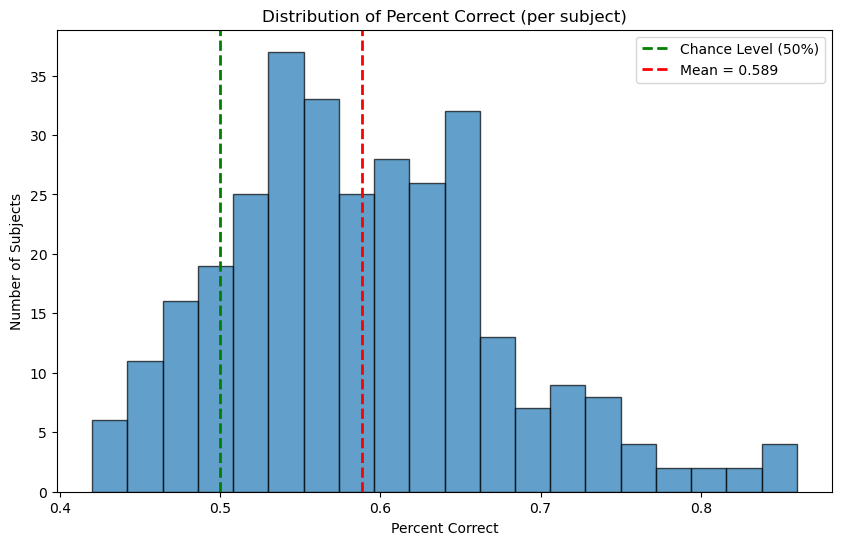

In [16]:
# Distribution of percent correct across subjects
plt.figure(figsize=(10, 6))
plt.hist(percent_cor_IDs['cor_ans'], bins=20, edgecolor="black", alpha=0.7)
plt.axvline(0.5, color='green', linestyle='dashed', linewidth=2, label='Chance Level (50%)')
plt.axvline(percent_cor_IDs['cor_ans'].mean(), color='red', 
            linestyle='dashed', linewidth=2, label=f'Mean = {percent_cor_IDs["cor_ans"].mean():.3f}')
plt.xlabel("Percent Correct")
plt.ylabel("Number of Subjects")
plt.title("Distribution of Percent Correct (per subject)")
plt.legend()
plt.show()

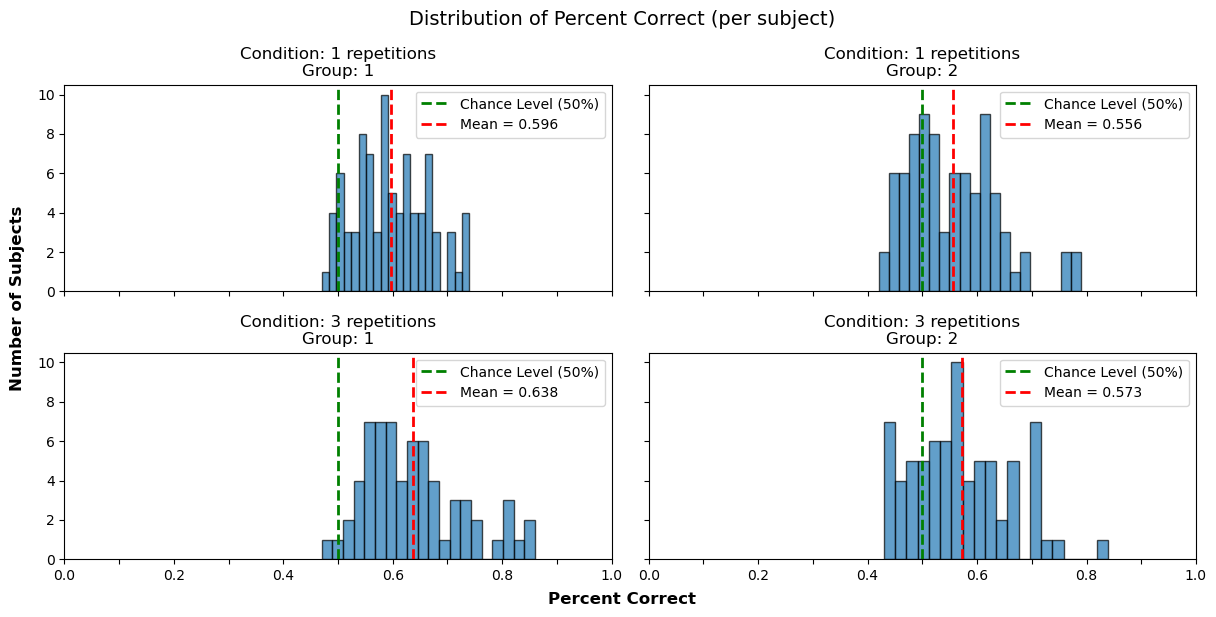

In [18]:
# Distribution of percent correct across subjects
# by groups
groups = np.tile(np.sort(percent_cor_IDs["group"].unique()), 2)
conds = np.repeat(
    np.sort(percent_cor_IDs["condition"].unique()), 
    2)
fig, axes = plt.subplots(2,2, # rows, cols
                         figsize=(12, 6), 
                         sharey=True,sharex=True # share x and y axis scales
                         )
axes = axes.ravel()

for ax, g, cond in zip(axes, groups, conds):
    data = percent_cor_IDs.loc[(percent_cor_IDs["group"] == g) & (percent_cor_IDs["condition"] == cond), "cor_ans"]
    ax.hist(data, bins=20, edgecolor="black", alpha=0.7)
    
    # Chance level
    ax.axvline(.50, color="green", linestyle="dashed", linewidth=2, label="Chance Level (50%)")
    # Group mean
    ax.axvline(data.mean(), color="red", linestyle="dashed", linewidth=2, label=f"Mean = {data.mean():.3f}")
    
    ax.set_title(f"Condition: {cond.split('_')[0]} repetitions\nGroup: {g[-1]}") # g = 'Group1' or 'Group2', so g[-1] is '1' or '2'
    ax.set_xlim(0,1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xticklabels([f"{x:.1f}" if i % 2 == 0 else '' for i, x in enumerate(np.arange(0, 1.1, 0.1))])
    ax.legend()


fig.text(-0.01, 0.5, 'Number of Subjects', va='center', rotation='vertical', fontsize=12, fontweight='bold')
fig.text(0.5, -0.01, 'Percent Correct', ha='center', fontsize=12, fontweight='bold')
fig.suptitle("Distribution of Percent Correct (per subject)", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Get unique subject IDs from data
all_IDs = data_test['subject_id'].unique()

# Compute difference
not_credited_yet = [id for id in all_IDs if id not in credited_IDs]

print(not_credited_yet)

[]


In [13]:
len(not_credited_yet) # Number of subjects not credited yet

0

In [19]:
credited_IDs = data_test['subject_id'].unique()

In [20]:
credited_IDs

[91884, 91746, 91362, 90803, 92618, ..., 92487, 91553, 91923, 92078, 92625]
Length: 309
Categories (309, int64): [90596, 90597, 90605, 90626, ..., 93067, 93073, 93082, 93095]

In [21]:
# IDs who completed the experiment more than once
ID_trial_count = data_test['subject_id'].value_counts()
(ID_trial_count
 .index[ np.where( ID_trial_count.values > 100 ) ] # IDs with more than 100 trials
 .tolist() # more readable format
 )

[]

In [22]:
# N per condition/group (before filters!)
data_test \
    .groupby(['condition','group'], observed=True, as_index=False)['subject_id'] \
    .nunique()

,condition,group,subject_id
0,1_Rep,Group1,87
1,1_Rep,Group2,83
2,3_Rep,Group1,65
3,3_Rep,Group2,74


In [23]:
# N total (before filters!)
data_test['subject_id'].nunique()

309

# d' by ID

Calculate d' with adjustments (for both hits and false alarms Macmillan & Kaplan, 1985), so that if there is a perfect (1) or terrible (0) hit, or fa, we still got a value (not infinity):
$$\text{Hit} = \frac{N_{hits} + 0.5}{N_{signal\_trials} + 1}$$

Same for FAs.

In [24]:
# Compute hits and number of signal trials per subject
hits_IDs = (
    data_test
    .loc[data_test['item_type'] == 'Target']
    .groupby('subject_id', observed=True)
    .agg(
        hits=('cor_ans', 'sum'),
        signal_trials=('cor_ans', 'count')
    )
    .reset_index()
)

# Compute unadjusted hit rate
hits_IDs['Hit_rate'] = hits_IDs['hits'] / hits_IDs['signal_trials']

# Apply Macmillan & Kaplan (1985) correction
hits_IDs['Hit_rate_adj'] = (hits_IDs['hits'] + 0.5) / (hits_IDs['signal_trials'] + 1)
hits_IDs

,subject_id,hits,signal_trials,Hit_rate,Hit_rate_adj
0,90596,29,50,0.58,0.578431
1,90597,35,50,0.70,0.696078
2,90605,30,50,0.60,0.598039
3,90626,25,50,0.50,0.500000
4,90630,25,50,0.50,0.500000
...,...,...,...,...,...
304,93059,28,50,0.56,0.558824
305,93067,36,50,0.72,0.715686
306,93073,28,50,0.56,0.558824
307,93082,34,50,0.68,0.676471


In [25]:
# Compute false alarms and number of noise trials per subject
fa_IDs = (
    data_test
    .loc[data_test['item_type'] == 'Foil']
    .groupby('subject_id', observed=True)
    .agg(
        # Count "l" responses as false alarms
        FA=('response', lambda x: (x == 'l').sum()),
        noise_trials=('response', 'count')
    )
    .reset_index()
)

# Compute unadjusted false alarm rate
fa_IDs['FA_rate'] = fa_IDs['FA'] / fa_IDs['noise_trials']

# Apply Macmillan & Kaplan (1985) correction
fa_IDs['FA_rate_adj'] = (fa_IDs['FA'] + 0.5) / (fa_IDs['noise_trials'] + 1)

fa_IDs

,subject_id,FA,noise_trials,FA_rate,FA_rate_adj
0,90596,31,50,0.62,0.617647
1,90597,27,50,0.54,0.539216
2,90605,16,50,0.32,0.323529
3,90626,26,50,0.52,0.519608
4,90630,26,50,0.52,0.519608
...,...,...,...,...,...
304,93059,21,50,0.42,0.421569
305,93067,30,50,0.60,0.598039
306,93073,18,50,0.36,0.362745
307,93082,19,50,0.38,0.382353


In [26]:
# Calculate d'
dprime_ID = pd.merge(hits_IDs, fa_IDs, on='subject_id')
dprime_ID['dprimes'] = [stats.norm.ppf(hit) - stats.norm.ppf( (fa) ) 
  for hit, fa 
  in zip(dprime_ID['Hit_rate_adj'], dprime_ID['FA_rate_adj'])
  ]

# Drop columns
dprime_ID = (dprime_ID
 .drop( columns={'hits', 'signal_trials', 'Hit_rate', 'FA', 'noise_trials', 'FA_rate'})
 .rename(columns = {'Hit_rate_adj':'Hit_rate',
                    'FA_rate_adj':'FA_rate'})
 )

dprime_ID

,subject_id,Hit_rate,FA_rate,dprimes
0,90596,0.578431,0.617647,-0.101425
1,90597,0.696078,0.539216,0.414697
2,90605,0.598039,0.323529,0.706127
3,90626,0.500000,0.519608,-0.049169
4,90630,0.500000,0.519608,-0.049169
...,...,...,...,...
304,93059,0.558824,0.421569,0.345869
305,93067,0.715686,0.598039,0.321799
306,93073,0.558824,0.362745,0.499118
307,93082,0.676471,0.382353,0.757159


In [27]:
# Add groups and conditions from percent_cor_IDs
dprime_ID = pd.merge(
    dprime_ID, 
    percent_cor_IDs[['subject_id','group','condition']], 
    on='subject_id'
    )
dprime_ID

,subject_id,Hit_rate,FA_rate,dprimes,group,condition
0,90596,0.578431,0.617647,-0.101425,Group2,1_Rep
1,90597,0.696078,0.539216,0.414697,Group1,1_Rep
2,90605,0.598039,0.323529,0.706127,Group1,3_Rep
3,90626,0.500000,0.519608,-0.049169,Group1,1_Rep
4,90630,0.500000,0.519608,-0.049169,Group2,1_Rep
...,...,...,...,...,...,...
304,93059,0.558824,0.421569,0.345869,Group1,3_Rep
305,93067,0.715686,0.598039,0.321799,Group1,3_Rep
306,93073,0.558824,0.362745,0.499118,Group2,1_Rep
307,93082,0.676471,0.382353,0.757159,Group2,1_Rep


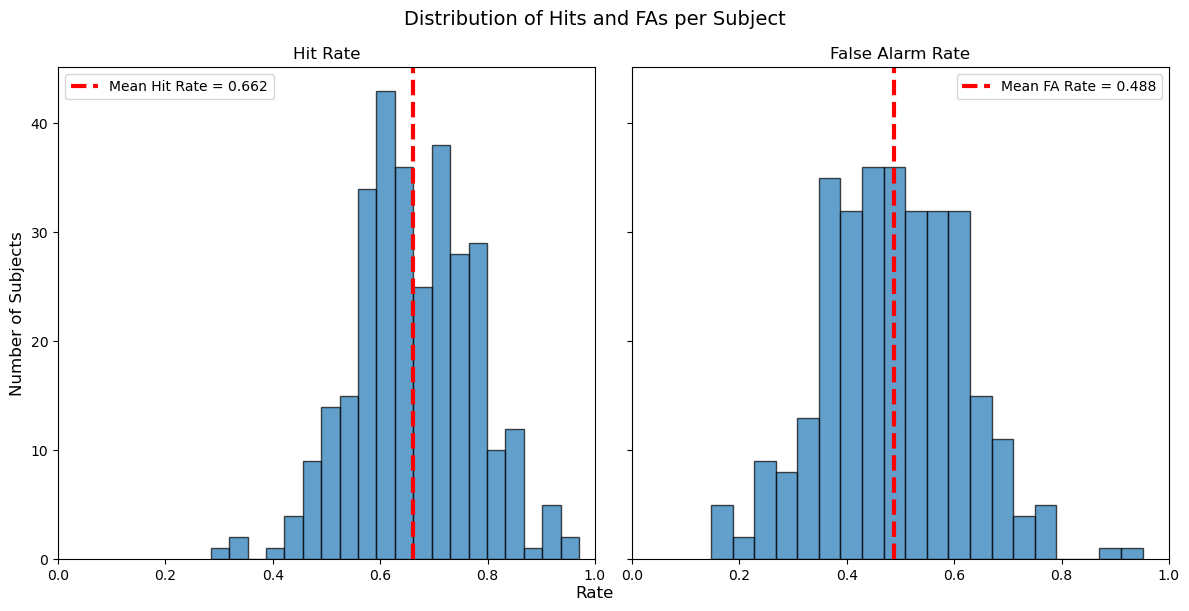

In [28]:
# Hits and FAs distribution (before filtering!)
fig, axes = plt.subplots(1, 2, # rows, cols
                         figsize=(12, 6), 
                         sharey=True,sharex=True # share x and y axis scales
                         )


axes[0].hist(dprime_ID['Hit_rate'], bins=20, edgecolor="black", alpha=0.7)
axes[1].hist(dprime_ID['FA_rate'], bins=20, edgecolor="black", alpha=0.7)

axes[0].set_xlim(0, 1)

# Mean
axes[0].axvline(dprime_ID['Hit_rate'].mean(), color="red", 
                linestyle="dashed", linewidth=3, 
                label=f"Mean Hit Rate = {dprime_ID['Hit_rate'].mean():.3f}")
axes[1].axvline(dprime_ID['FA_rate'].mean(), color="red", 
                linestyle="dashed", linewidth=3, 
                label=f"Mean FA Rate = {dprime_ID['FA_rate'].mean():.3f}")

axes[0].set_title("Hit Rate")
axes[1].set_title("False Alarm Rate") 

fig.text(0.5, 0, "Rate", ha="center", fontsize=12)

axes[0].legend()
axes[1].legend()

axes[0].set_ylabel("Number of Subjects", fontsize=12)
fig.suptitle("Distribution of Hits and FAs per Subject", fontsize=14)
plt.tight_layout()
plt.show()

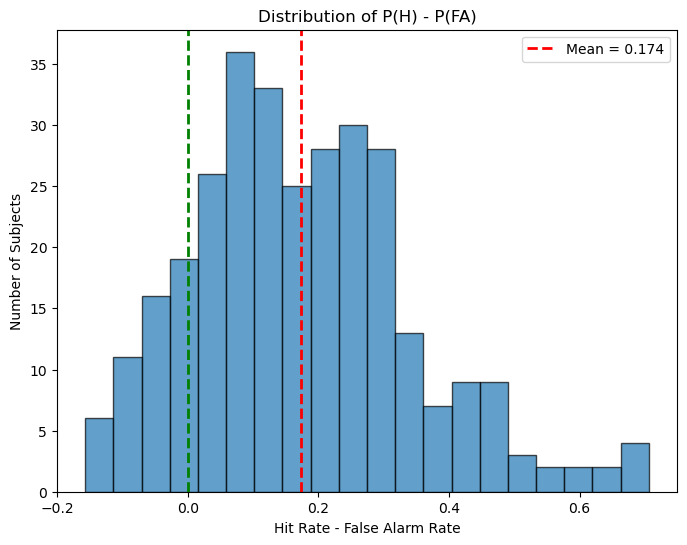

In [29]:
# p(H) - p(FA)
plt.figure(figsize=(8, 6))
plt.hist(dprime_ID['Hit_rate'] - dprime_ID['FA_rate'], bins=20, edgecolor="black", alpha=0.7)
plt.axvline(0, color='green', linestyle='dashed', linewidth=2)
plt.axvline((dprime_ID['Hit_rate'] - dprime_ID['FA_rate']).mean(), 
            color='red', linestyle='dashed', linewidth=2,
            label=f'Mean = {(dprime_ID["Hit_rate"] - dprime_ID["FA_rate"]).mean():.3f}')
plt.xlabel("Hit Rate - False Alarm Rate")
plt.ylabel("Number of Subjects")
plt.title("Distribution of P(H) - P(FA)")
plt.legend()
plt.show()

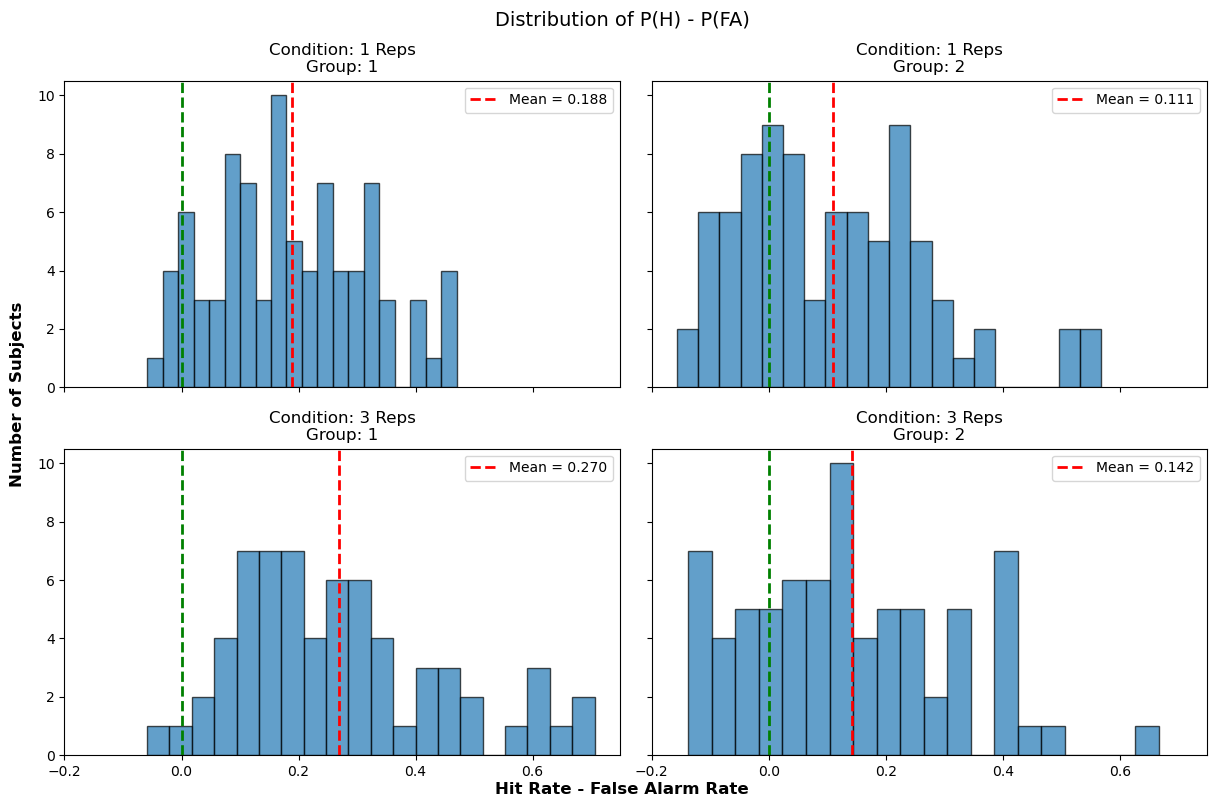

In [37]:
# p(H) - p(FA) plot by group and condition (before filtering!)
groups = np.tile(np.sort(dprime_ID['group'].unique()), 2)
conds = np.repeat(np.sort(dprime_ID['condition'].unique()), 2)

fig, axes = plt.subplots(2, 2, # rows, cols
                         figsize=(12, 8),
                         sharex=True, sharey=True # share x and y axis scales
                         )
axes = axes.ravel()
for ax, g, cond in zip(axes, groups, conds):
    data = (
        dprime_ID.loc[(dprime_ID['group'] == g) & (dprime_ID['condition'] == cond), 'Hit_rate'] - 
        dprime_ID.loc[(dprime_ID['group'] == g) & (dprime_ID['condition'] == cond), 'FA_rate']
        )
    ax.hist(data, bins=20, edgecolor="black", alpha=0.7)
    
    # Chance level
    ax.axvline(0, color='green', linestyle='dashed', linewidth=2)
    # Group & Condition mean
    ax.axvline(data.mean(), color='red', linestyle='dashed', linewidth=2,
               label=f'Mean = {data.mean():.3f}')
    
    ax.set_title(f"Condition: {cond[0]} Reps\nGroup: {g[-1]}") # g = 'Group1' or 'Group2', so g[-1] is '1' or '2'
    #ax.set_xlabel("Hit Rate - False Alarm Rate")
    ax.legend()

fig.text(0.5, 0, "Hit Rate - False Alarm Rate", ha="center", fontsize=12, fontweight='bold')
fig.text(-0.01, 0.5, 'Number of Subjects', va='center', rotation='vertical', fontsize=12, fontweight='bold')
fig.suptitle("Distribution of P(H) - P(FA)", fontsize=14)
plt.tight_layout()
plt.show()

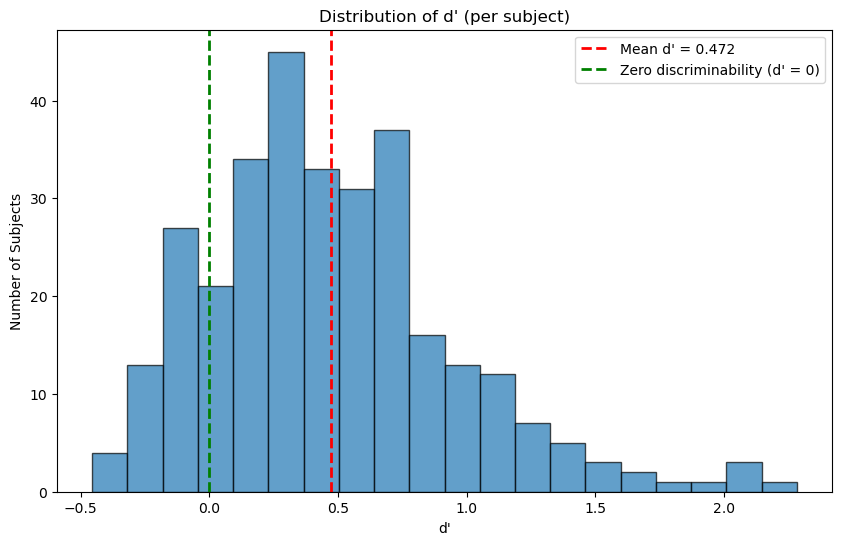

In [33]:
# d' (before filtering!)
plt.figure(figsize=(10, 6))
plt.hist(dprime_ID['dprimes'], bins=20, edgecolor="black", alpha=0.7)
plt.axvline(np.mean(dprime_ID['dprimes']), color='red', linestyle='dashed', linewidth=2, label=f'Mean d\' = {np.mean(dprime_ID["dprimes"]):.3f}')
plt.axvline(0, color='green', linestyle='dashed', linewidth=2, label="Zero discriminability (d' = 0)")
plt.xlabel("d'")
plt.ylabel("Number of Subjects")
plt.title("Distribution of d' (per subject)")
plt.legend()
plt.show()

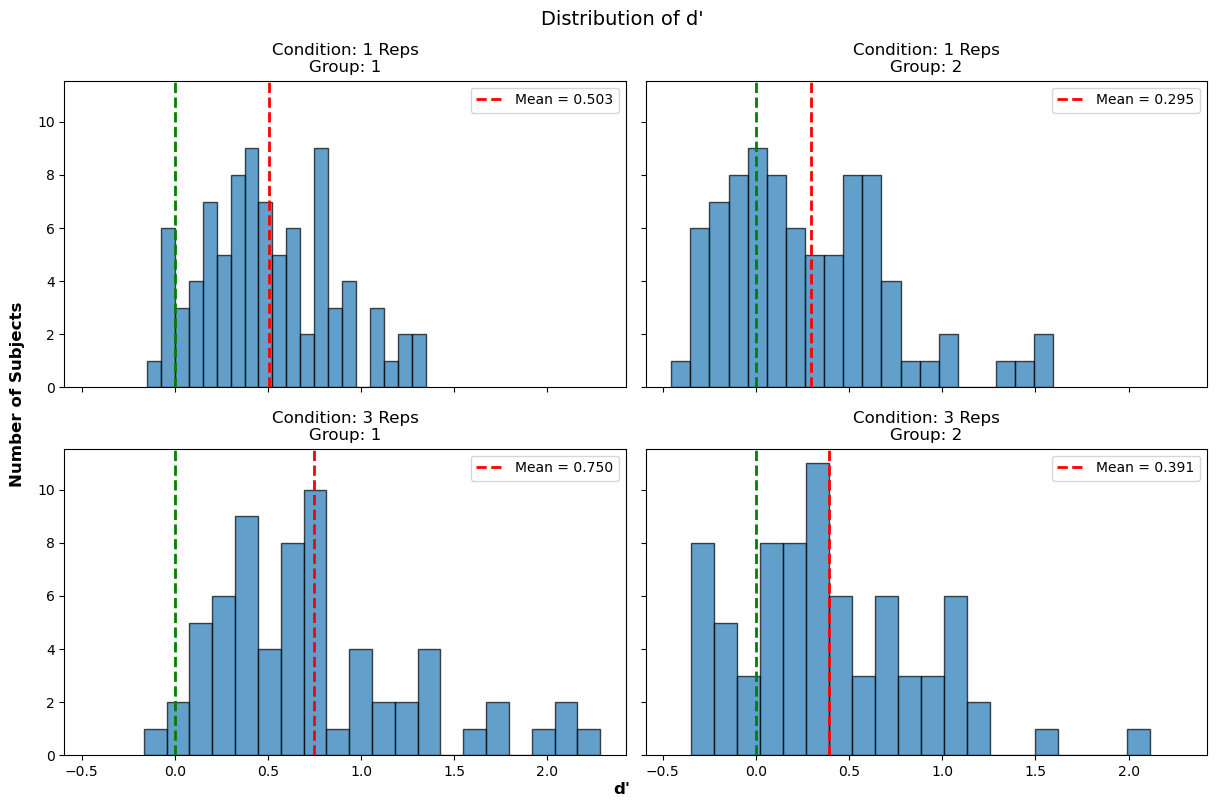

In [36]:
# d' plot by group and condition (before filtering!)
groups = np.tile(np.sort(dprime_ID['group'].unique()), 2)
conds = np.repeat(np.sort(dprime_ID['condition'].unique()), 2)

fig, axes = plt.subplots(2, 2, # rows, cols
                         figsize=(12, 8),
                         sharex=True, sharey=True # share x and y axis scales
                         )
axes = axes.ravel()
for ax, g, cond in zip(axes, groups, conds):
    data = dprime_ID.loc[(dprime_ID['group'] == g) & (dprime_ID['condition'] == cond), 'dprimes']
    ax.hist(data, bins=20, edgecolor="black", alpha=0.7)
    
    # Chance level
    ax.axvline(0, color='green', linestyle='dashed', linewidth=2)
    # Group & Condition mean
    ax.axvline(data.mean(), color='red', linestyle='dashed', linewidth=2,
               label=f'Mean = {data.mean():.3f}')
    
    ax.set_title(f"Condition: {cond[0]} Reps\nGroup: {g[-1]}") # g = 'Group1' or 'Group2', so g[-1] is '1' or '2'
    #ax.set_xlabel("Hit Rate - False Alarm Rate")
    ax.legend()

fig.text(0.5, 0, "d'", ha="center", fontsize=12, fontweight='bold')
fig.text(-0.01, 0.5, 'Number of Subjects', va='center', rotation='vertical', fontsize=12, fontweight='bold')
fig.suptitle("Distribution of d'", fontsize=14)
plt.tight_layout()
plt.show()

## Filter by Hit - FA

In [39]:
# Conditional thresholds for both conditions and groups
threshold_by_cond = (
    (dprime_ID['Hit_rate'] - dprime_ID['FA_rate'])
    .groupby([dprime_ID['condition'], dprime_ID['group']], observed=True)
    .quantile(0.25) # top 75% of subjects in each condition/group
)
threshold_by_cond = np.maximum(threshold_by_cond,0) # make sure thresholds are not negative

# thresholds are:
print(f'Thresholds are:')
for idx, val in threshold_by_cond.items():
    print(f'  {idx}: {val:.3f}')

conditions = [
    (dprime_ID['condition'] == '1_Rep') & (dprime_ID['group'] == 'Group1') &
    ((dprime_ID['Hit_rate'] - dprime_ID['FA_rate']) >= threshold_by_cond[('1_Rep','Group1')]),
    
    (dprime_ID['condition'] == '1_Rep') & (dprime_ID['group'] == 'Group2') &
    ((dprime_ID['Hit_rate'] - dprime_ID['FA_rate']) >= threshold_by_cond[('1_Rep','Group2')]),
    
    (dprime_ID['condition'] == '3_Rep') & (dprime_ID['group'] == 'Group1') &
    ((dprime_ID['Hit_rate'] - dprime_ID['FA_rate']) >= threshold_by_cond[('3_Rep','Group1')]),
    
    (dprime_ID['condition'] == '3_Rep') & (dprime_ID['group'] == 'Group2') &
    ((dprime_ID['Hit_rate'] - dprime_ID['FA_rate']) >= threshold_by_cond[('3_Rep','Group2')]),
]
choices = [True, True, True, True] # conditions are for good subjects, so defaule is False (next line)

dprime_ID['good_subj'] = np.select(conditions, choices, default=False)
bad_subjects = dprime_ID.loc[dprime_ID['good_subj'] == False,'subject_id'].tolist()

Thresholds are:
  ('1_Rep', 'Group1'): 0.088
  ('1_Rep', 'Group2'): 0.000
  ('3_Rep', 'Group1'): 0.137
  ('3_Rep', 'Group2'): 0.020


In [41]:
# Add column good_subj (filter by Hit - FA)
data_test = (pd.merge(data_test, 
                               dprime_ID.loc[:,['subject_id','good_subj']], 
                               on='subject_id')
                      )
data_memory = (pd.merge(data_memory, 
                               dprime_ID.loc[:,['subject_id','good_subj']], 
                               on='subject_id')
                      )

In [48]:
# save filtered data
filtered_data_test = data_test[data_test['good_subj'] == True].copy().reset_index(drop=True)
filtered_data_memory = data_memory[data_memory['good_subj'] == True].copy().reset_index(drop=True)

In [50]:
# N good subjects
(filtered_data_test
 .groupby(['condition','group'], observed=True)['subject_id']
 .nunique()
 .reset_index(name='N_subj')
 )

,condition,group,N_subj
0,1_Rep,Group1,65
1,1_Rep,Group2,61
2,3_Rep,Group1,50
3,3_Rep,Group2,56


In [47]:
# Total N good subjects
print(f"Total number of good subjects: {filtered_data_test['subject_id'].nunique()}")
print(f"Total number of all subjects: {data_test['subject_id'].nunique()}")
print(f"Proportion of good subjects: {filtered_data_test['subject_id'].nunique() / data_test['subject_id'].nunique():.3f}")

Total number of good subjects: 232
Total number of all subjects: 309
Proportion of good subjects: 0.751


# d' by item

In [51]:
# Proportion Yes by image_id
df_by_item = (filtered_data_test
            .groupby(['image_id','condition','group'], observed=True)
            .agg(n_subj=('cor_ans', 'size'),
                n_yes=('response', lambda x: (x == "l").sum()),
                item_type=('item_type', 'first'),
                category_name=('category_name', 'first'),
                distinct_rating=('distinct_rating', 'first'),
                distinct_type=('distinct_type', 'first') 
                )
            .reset_index()
            .assign(prop_yes=lambda df: (df['n_yes']+0.5) / (df['n_subj']+1), # Apply Macmillan & Kaplan (1985) correction
                    resp_type = lambda df: np.where(df['item_type'] == 'Target', 'Hit', 'FA')
                    )
            )
df_by_item

,image_id,condition,group,n_subj,n_yes,item_type,category_name,distinct_rating,distinct_type,prop_yes,resp_type
0,3,1_Rep,Group1,65,20,Foil,Andesite,3.17,Bottom,0.310606,FA
1,3,1_Rep,Group2,61,32,Target,Andesite,3.17,Bottom,0.524194,Hit
2,3,3_Rep,Group1,50,14,Foil,Andesite,3.17,Bottom,0.284314,FA
3,3,3_Rep,Group2,56,28,Target,Andesite,3.17,Bottom,0.500000,Hit
4,4,1_Rep,Group1,65,37,Foil,Andesite,3.18,Bottom,0.568182,FA
...,...,...,...,...,...,...,...,...,...,...,...
395,472,3_Rep,Group2,56,14,Foil,Shale,2.55,Bottom,0.254386,FA
396,476,1_Rep,Group1,65,46,Target,Shale,2.48,Bottom,0.704545,Hit
397,476,1_Rep,Group2,61,32,Foil,Shale,2.48,Bottom,0.524194,FA
398,476,3_Rep,Group1,50,40,Target,Shale,2.48,Bottom,0.794118,Hit


In [52]:
# Wide format with H and FAs for each image_id
df_by_item_wide = df_by_item.pivot(index=["image_id","condition"], 
                                   columns="resp_type", 
                                   values="prop_yes").reset_index()
df_by_item_wide

resp_type,image_id,condition,FA,Hit
0,3,1_Rep,0.310606,0.524194
1,3,3_Rep,0.284314,0.500000
2,4,1_Rep,0.568182,0.556452
3,4,3_Rep,0.460784,0.447368
4,6,1_Rep,0.556452,0.734848
...,...,...,...,...
195,471,3_Rep,0.421569,0.675439
196,472,1_Rep,0.362903,0.598485
197,472,3_Rep,0.254386,0.480392
198,476,1_Rep,0.524194,0.704545


In [53]:
# convert resp_type to categorical
df_by_item['resp_type'] = df_by_item['resp_type'].astype('category')

## LM: H and FAs ~ cond*distinct

In [55]:
# Linear regression
m1 = smf.ols(
    "prop_yes ~ condition * distinct_type * resp_type",
    data=df_by_item
    ) \
    .fit(cov_type='HC3') # hc3 - heteroscedasticity-corrected coefficient covariance matrix

anova_lm(m1, typ = 2).round(3) # ANOVA table with type II sums of squares

,sum_sq,df,F,PR(>F)
condition,0.083,1.0,5.238,0.023
distinct_type,2.562,1.0,161.621,0.000
resp_type,9.244,1.0,583.145,0.000
condition:distinct_type,0.101,1.0,6.358,0.012
condition:resp_type,0.126,1.0,7.957,0.005
distinct_type:resp_type,3.796,1.0,239.458,0.000
condition:distinct_type:resp_type,0.026,1.0,1.659,0.199
Residual,6.214,392.0,NaN,NaN


In [56]:
# LM-like summary
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:               prop_yes   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     182.8
Date:                Tue, 16 Jun 2026   Prob (F-statistic):          3.07e-119
Time:                        16:31:37   Log-Likelihood:                 265.36
No. Observations:                 400   AIC:                            -514.7
Df Residuals:                     392   BIC:                            -482.8
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

**Post-hoc Comparisons**

Contrasts:

- For Hits: 
    * 1 vs 3 (low)
    * 1 vs 3 (high)
    * low vs high (1)
    * low vs high (3)

- Similarly for FAs:
    * 1 vs 3 (low)
    * 1 vs 3 (high)
    * low vs high (1)
    * low vs high (3)

Regular formula to calculate t-statistics:

$SE = \sqrt{MSE \cdot \sum_i \frac{w_i^2}{n_i}}$, where $MSE = \frac{SS_{residual}}{df_{residual}}$, and $df = df_{residual}$. Then $t = \frac{\text{Contrast}_i \cdot w_i}{SE}$. And finally, calculate p-value using df from the model (ANOVA), in our case $df_{residual} = 400 - 8 = 392$.

But when we try to account for **different variances across groups of comparison**, we need to use Welch's t-test (unequal variance t-test):

$$SE = \sqrt{\sum_i \frac{w_i^2 s_i^2}{n_i}}$$

$$df = \frac{\left(\sum_i \frac{w_i^2 s_i^2}{n_i}\right)^2}{\sum_i \frac{\left(\frac{w_i^2 s_i^2}{n_i}\right)^2}{n_i - 1}}$$

In [57]:
# ========== Bonferroni-corrected post hoc contrasts (account for different variances) ==========
anova_table = anova_lm(m1, typ = 2)
mse = anova_table['sum_sq']['Residual'] / anova_table['df']['Residual']

# Get group means
group_means = df_by_item.groupby(['condition','distinct_type','resp_type'], observed=True)['prop_yes'].mean()
group_vars = df_by_item.groupby(['condition','distinct_type','resp_type'], observed=True)['prop_yes'].var() # need to account for different variances across groups
n = df_by_item.groupby(['condition','distinct_type','resp_type'], observed=True).size() # Sample sizes

# Manually specify contrasts based on the means and MSE from the ANOVA
contrasts = {
    # ========== Hits ==========
    'Low hits 1 rep vs 3 rep': (0, 1, 0, 0,
                                0, -1, 0, 0),
    'High hits 1 rep vs 3 rep': (0, 0, 0, 1,
                                 0, 0, 0, -1),
    'Low vs high hits (1 rep)': (0, 1, 0, -1,
                                 0, 0, 0, 0),
    'Low vs high hits (3 rep)': (0, 0, 0, 0,
                                 0, 1, 0, -1),
    # ========== FAs ==========
    'Low FAs 1 rep vs 3 rep': (1, 0, 0, 0,
                               -1, 0, 0, 0),
    'High FAs 1 rep vs 3 rep': (0, 0, 1, 0,
                                0, 0, -1, 0),
    'Low vs high FAs (1 rep)': (1, 0, -1, 0,
                                0, 0, 0, 0),
    'Low vs high FAs (3 rep)': (0, 0, 0, 0,
                                1, 0, -1, 0),
}

contrasts_results = {}
n_comparison = len(contrasts)

for contrast_name, weights in contrasts.items():
    weights = np.array(weights)
    contrast_estimate = weights @ group_means
    
    # Per-group variance contribution
    var_terms = (weights**2) * (group_vars / n) # account for different variances and sample sizes
    se = np.sqrt(var_terms.sum())
    
    # Welch-Satterthwaite degrees of freedom
    df_ws = var_terms.sum()**2 / ((var_terms**2) / (n - 1)).sum()
    
    t_stat = contrast_estimate / se
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=df_ws)
    p_adjusted = min(p_value * n_comparison, 1.0)
    sig = "***" if p_adjusted < 0.001 else "**" if p_adjusted < 0.01 else "*" if p_adjusted < 0.05 else ""
    
    contrasts_results[contrast_name] = {
        'estimate': contrast_estimate,
        't_stat': t_stat,
        'df': df_ws,          # will vary per contrast now
        'p_value': p_value,
        'p_adjusted': p_adjusted,
        'significance': sig
    }

# Print results in a table format
m1_posthoc_df = pd.DataFrame(contrasts_results).T
num_cols = ['estimate', 't_stat', 'p_value', 'p_adjusted']
m1_posthoc_df[num_cols] = m1_posthoc_df[num_cols].astype(float)
m1_posthoc_df = m1_posthoc_df.round(3)
m1_posthoc_df

,estimate,t_stat,df,p_value,p_adjusted,significance
Low hits 1 rep vs 3 rep,-0.030,-1.754,164.774836,0.081,0.650,
High hits 1 rep vs 3 rep,-0.135,-3.935,28.073934,0.000,0.004,**
Low vs high hits (1 rep),0.003,0.099,21.976806,0.922,1.000,
Low vs high hits (3 rep),-0.102,-4.273,25.299982,0.000,0.002,**
Low FAs 1 rep vs 3 rep,0.019,0.810,163.121276,0.419,1.000,
High FAs 1 rep vs 3 rep,-0.017,-0.611,28.614111,0.546,1.000,
Low vs high FAs (1 rep),0.383,16.711,43.010455,0.000,0.000,***
Low vs high FAs (3 rep),0.347,12.589,38.155228,0.000,0.000,***


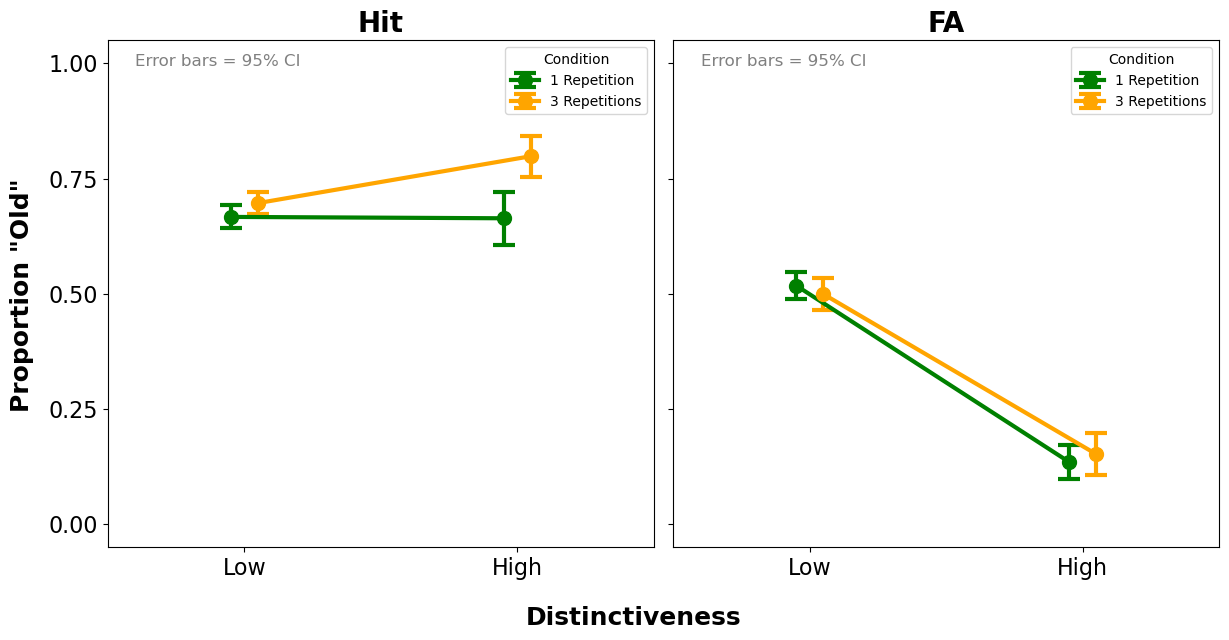

In [58]:
# Plot 
# Summary stats for plotting
summary = (
    df_by_item
    .groupby(["condition", "resp_type", "distinct_type"], observed=False)
    .agg(
        mean_prop=("prop_yes", "mean"),
        n=("prop_yes", "size"),
        sd=("prop_yes", "std")
    )
    .reset_index()
)
summary["se"] = summary["sd"] / np.sqrt(summary["n"])
summary["ci95"] = summary["se"] * stats.t.ppf(0.975, summary["n"] - 1)


fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

resp_levels = ["Hit", "FA"]
conditions = sorted(df_by_item["condition"].unique())
x_levels = sorted(df_by_item["distinct_type"].unique())
x_pos = np.arange(len(x_levels))

# color
color_map = {
    "1_Rep": "green",
    "3_Rep": "orange"
}
condition_label_map = {
    "1_Rep": "1 Repetition",
    "3_Rep": "3 Repetitions"
}
# slighly to the left/right from the center of the x-ticks
offset_map = {
    "1_Rep": -0.05,
    "3_Rep":  0.05
}
x_label_map = {
    "Bottom": "Low",
    "Top": "High"
}

for ax, resp in zip(axes, resp_levels):

    for cond in conditions:
        summ = summary[
            (summary["resp_type"] == resp) &
            (summary["condition"] == cond)
        ]

        means = []
        cis = []

        for lvl in x_levels:
            row = summ[summ["distinct_type"] == lvl].iloc[0]
            means.append(row["mean_prop"])
            cis.append(row["ci95"])

        ax.errorbar(
            x_pos + offset_map[cond], # offset for visibility
            means,
            yerr=cis,
            fmt="o-", # o means draw the mean circle, - means connect with line
            capthick=3, # 
            capsize=8,
            linewidth=3,
            markersize=10,
            color=color_map[cond],
            label=condition_label_map[cond]
        )

    ax.set_title(resp, fontsize=20, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([x_label_map[lvl] for lvl in x_levels], fontsize=16)
    ax.set_xlim(-0.5, len(x_levels) - 0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.25))
    ax.tick_params(axis="both", labelsize=16)
    ax.text(0.05, 0.95, f'Error bars = 95% CI', transform=ax.transAxes, fontsize=12, color='gray')
    ax.legend(title="Condition")

fig.text(-0.02, 0.5, 'Proportion "Old"', va="center",
         rotation="vertical", fontsize=18, fontweight="bold")
fig.text(0.5, -0.05, "Distinctiveness", ha="center",
         fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()

# Split-Half

In [59]:
# add response types to filtered_data_test
conditions = [
    (filtered_data_test['item_type'] == 'Target') & (filtered_data_test['cor_ans'] == True),
    (filtered_data_test['item_type'] == 'Target') & (filtered_data_test['cor_ans'] == False),
    (filtered_data_test['item_type'] == 'Foil') & (filtered_data_test['cor_ans'] == True),
    (filtered_data_test['item_type'] == 'Foil') & (filtered_data_test['cor_ans'] == False),
]

choices = ['Hit', 'Miss', 'CR', 'FA']

filtered_data_test['resp_type'] = np.select(conditions, choices, default=None)
filtered_data_test

,trial_index,subject_id,group,condition,task,item_type,response,correct_response,cor_ans,rt,category_name,category,broad_category,image_png,image_id,distinct_rating,distinct_type,good_subj,resp_type
0,311,91746,Group2,3_Rep,test_phase,Target,l,l,True,1776.0,Gneiss,13,M,M_Gneiss_15.png,207,3.11,Bottom,True,Hit
1,313,91746,Group2,3_Rep,test_phase,Target,l,l,True,767.0,Rock Salt,28,S,S_Rock Salt_13.png,445,7.58,Top,True,Hit
2,315,91746,Group2,3_Rep,test_phase,Target,l,l,True,779.0,Pegmatite,7,I,I_Pegmatite_03.png,99,7.24,Top,True,Hit
3,317,91746,Group2,3_Rep,test_phase,Target,l,l,True,805.0,Gneiss,13,M,M_Gneiss_10.png,202,3.09,Bottom,True,Hit
4,319,91746,Group2,3_Rep,test_phase,Foil,a,a,True,924.0,Rhyolite,10,I,I_Rhyolite_16.png,160,2.19,Bottom,True,CR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23195,501,92625,Group2,3_Rep,test_phase,Foil,a,a,True,1088.0,Obsidian,6,I,I_Obsidian_05.png,85,7.32,Top,True,CR
23196,503,92625,Group2,3_Rep,test_phase,Target,l,l,True,815.0,Gneiss,13,M,M_Gneiss_10.png,202,3.09,Bottom,True,Hit
23197,505,92625,Group2,3_Rep,test_phase,Foil,l,a,False,1000.0,Marble,15,M,M_Marble_04.png,228,3.15,Bottom,True,FA
23198,507,92625,Group2,3_Rep,test_phase,Target,l,l,True,683.0,Gneiss,13,M,M_Gneiss_14.png,206,3.41,Bottom,True,Hit


In [60]:
# ---------- Hits data for split-half reliability analysis ----------

# ---------- 1 Rep ----------

# ---------- Group 1 ----------

sh_df_hits_1rep_gr1_long = (
    (filtered_data_test.loc[(filtered_data_test['condition']=='1_Rep') & 
                            (filtered_data_test['group']=='Group1') & 
                            (filtered_data_test['item_type']=='Target'), 
                            ['subject_id','condition','group','image_id','resp_type', 'item_type']])
    .copy()
    )
sh_df_hits_1rep_gr1_long['is_hit'] = np.where(sh_df_hits_1rep_gr1_long['resp_type']=='Hit', 1, 0)  # is hit or miss
sh_df_hits_1rep_gr1_long = sh_df_hits_1rep_gr1_long[['subject_id', 'image_id', 'is_hit']]  
# pivot a table wider
sh_df_hits_1rep_gr1 = sh_df_hits_1rep_gr1_long.pivot(index='image_id', columns='subject_id', values='is_hit')


# ---------- Group 2 ----------

sh_df_hits_1rep_gr2_long = (
    (filtered_data_test.loc[(filtered_data_test['condition']=='1_Rep') & 
                            (filtered_data_test['group']=='Group2') & 
                            (filtered_data_test['item_type']=='Target'), 
                            ['subject_id','condition','group','image_id','resp_type', 'item_type']])
    .copy()
    )
sh_df_hits_1rep_gr2_long['is_hit'] = np.where(sh_df_hits_1rep_gr2_long['resp_type']=='Hit', 1, 0)  
sh_df_hits_1rep_gr2_long = sh_df_hits_1rep_gr2_long[['subject_id', 'image_id', 'is_hit']]  
# pivot a table wider
sh_df_hits_1rep_gr2 = sh_df_hits_1rep_gr2_long.pivot(index='image_id', columns='subject_id', values='is_hit')


# ---------- 3 Rep ----------

# ---------- Group 1 ----------

sh_df_hits_3rep_gr1_long = (
    (filtered_data_test.loc[(filtered_data_test['condition']=='3_Rep') & 
                            (filtered_data_test['group']=='Group1') & 
                            (filtered_data_test['item_type']=='Target'), 
                            ['subject_id','condition','group','image_id','resp_type', 'item_type']])
    .copy()
    )
sh_df_hits_3rep_gr1_long['is_hit'] = np.where(sh_df_hits_3rep_gr1_long['resp_type']=='Hit', 1, 0)  
sh_df_hits_3rep_gr1_long = sh_df_hits_3rep_gr1_long[['subject_id', 'image_id', 'is_hit']]  
# pivot a table wider
sh_df_hits_3rep_gr1 = sh_df_hits_3rep_gr1_long.pivot(index='image_id', columns='subject_id', values='is_hit')

# ---------- Group 2 ----------

sh_df_hits_3rep_gr2_long = (
    (filtered_data_test.loc[(filtered_data_test['condition']=='3_Rep') & 
                            (filtered_data_test['group']=='Group2') & 
                            (filtered_data_test['item_type']=='Target'), 
                            ['subject_id','condition','group','image_id','resp_type', 'item_type']])
    .copy()
    )
sh_df_hits_3rep_gr2_long['is_hit'] = np.where(sh_df_hits_3rep_gr2_long['resp_type']=='Hit', 1, 0)  
sh_df_hits_3rep_gr2_long = sh_df_hits_3rep_gr2_long[['subject_id', 'image_id', 'is_hit']]  
# pivot a table wider
sh_df_hits_3rep_gr2 = sh_df_hits_3rep_gr2_long.pivot(index='image_id', columns='subject_id', values='is_hit')

In [62]:
# Example of resulting tables:
# rows - image_id, columns - subject_id, values - 1 for hit, 0 for miss
sh_df_hits_3rep_gr2.head(10)

subject_id,91746,92208,91155,90707,91388,90950,92523,91224,91916,92252,...,90838,92458,91551,91813,92629,90680,91557,90645,91955,92625
image_id,,,,,,,,,,,,,,,,,,,,,
3,0,1,0,1,1,1,0,0,1,0,...,0,1,0,1,0,1,1,1,0,0
4,1,1,0,1,1,0,1,1,0,0,...,0,1,0,0,1,0,1,0,0,1
9,1,1,1,1,1,1,1,1,1,1,...,1,1,0,0,1,1,1,0,1,1
24,1,0,1,0,1,1,1,1,0,0,...,1,1,1,0,1,1,1,1,0,1
26,0,1,1,1,1,1,0,1,1,0,...,1,1,0,1,0,0,1,1,1,1
29,0,1,1,1,0,1,1,1,1,1,...,1,1,1,1,0,1,0,1,1,0
33,1,1,1,1,0,1,1,1,1,1,...,0,1,0,1,0,1,1,1,0,0
42,0,1,0,1,1,1,0,1,1,1,...,0,1,1,0,1,1,1,1,0,0
47,1,1,0,1,1,1,1,1,1,1,...,1,1,1,0,1,1,0,1,1,1


In [63]:
# ---------- FA data for split-half reliability analysis ----------


# ---------- 1 Rep ----------

# ---------- Group 1 ----------

sh_df_fa_1rep_gr1_long = (
    (filtered_data_test.loc[(filtered_data_test['condition']=='1_Rep') & 
                            (filtered_data_test['group']=='Group1') & 
                            (filtered_data_test['item_type']=='Foil'), 
                            ['subject_id','condition','group','image_id','resp_type', 'item_type']])
    .copy()
    )
sh_df_fa_1rep_gr1_long['is_fa'] = np.where(sh_df_fa_1rep_gr1_long['resp_type']=='FA', 1, 0)  # is fa or cr
sh_df_fa_1rep_gr1_long
sh_df_fa_1rep_gr1_long = sh_df_fa_1rep_gr1_long[['subject_id', 'image_id', 'is_fa']]  
# # pivot a table wider
sh_df_fa_1rep_gr1 = sh_df_fa_1rep_gr1_long.pivot(index='image_id', columns='subject_id', values='is_fa')


# ---------- Group 2 ----------

sh_df_fa_1rep_gr2_long = (
    (filtered_data_test.loc[(filtered_data_test['condition']=='1_Rep') & 
                            (filtered_data_test['group']=='Group2') & 
                            (filtered_data_test['item_type']=='Foil'), 
                            ['subject_id','condition','group','image_id','resp_type', 'item_type']])
    .copy()
    )
sh_df_fa_1rep_gr2_long['is_fa'] = np.where(sh_df_fa_1rep_gr2_long['resp_type']=='FA', 1, 0)  
sh_df_fa_1rep_gr2_long = sh_df_fa_1rep_gr2_long[['subject_id', 'image_id', 'is_fa']]  
# pivot a table wider
sh_df_fa_1rep_gr2 = sh_df_fa_1rep_gr2_long.pivot(index='image_id', columns='subject_id', values='is_fa')


# ---------- 3 Rep ----------

# ---------- Group 1 ----------

sh_df_fa_3rep_gr1_long = (
    (filtered_data_test.loc[(filtered_data_test['condition']=='3_Rep') & 
                            (filtered_data_test['group']=='Group1') & 
                            (filtered_data_test['item_type']=='Foil'), 
                            ['subject_id','condition','group','image_id','resp_type', 'item_type']])
    .copy()
    )
sh_df_fa_3rep_gr1_long['is_fa'] = np.where(sh_df_fa_3rep_gr1_long['resp_type']=='FA', 1, 0)  # is fa or cr
sh_df_fa_3rep_gr1_long
sh_df_fa_3rep_gr1_long = sh_df_fa_3rep_gr1_long[['subject_id', 'image_id', 'is_fa']]  
# # pivot a table wider
sh_df_fa_3rep_gr1 = sh_df_fa_3rep_gr1_long.pivot(index='image_id', columns='subject_id', values='is_fa')


# ---------- Group 2 ----------

sh_df_fa_3rep_gr2_long = (
    (filtered_data_test.loc[(filtered_data_test['condition']=='3_Rep') & 
                            (filtered_data_test['group']=='Group2') & 
                            (filtered_data_test['item_type']=='Foil'), 
                            ['subject_id','condition','group','image_id','resp_type', 'item_type']])
    .copy()
    )
sh_df_fa_3rep_gr2_long['is_fa'] = np.where(sh_df_fa_3rep_gr2_long['resp_type']=='FA', 1, 0)  
sh_df_fa_3rep_gr2_long = sh_df_fa_3rep_gr2_long[['subject_id', 'image_id', 'is_fa']]  
# pivot a table wider
sh_df_fa_3rep_gr2 = sh_df_fa_3rep_gr2_long.pivot(index='image_id', columns='subject_id', values='is_fa')

In [64]:
# Example of resulting tables:
# rows - image_id, columns - subject_id, values - 1 for FA, 0 for CR
sh_df_fa_3rep_gr2.head(10)

subject_id,91746,92208,91155,90707,91388,90950,92523,91224,91916,92252,...,90838,92458,91551,91813,92629,90680,91557,90645,91955,92625
image_id,,,,,,,,,,,,,,,,,,,,,
6,1,0,1,1,0,0,0,0,0,1,...,0,0,1,0,1,0,1,0,1,1
8,0,1,1,0,0,1,1,1,1,1,...,0,1,1,1,1,1,1,0,1,0
10,0,1,1,0,1,1,1,1,1,0,...,1,0,0,0,0,0,1,0,0,0
17,1,1,0,0,1,1,1,1,0,1,...,1,1,0,1,0,1,1,1,1,1
18,0,1,0,1,0,1,1,1,1,0,...,0,1,0,0,1,1,1,1,1,1
25,1,1,1,1,0,1,0,0,1,1,...,1,0,1,0,0,0,1,0,1,0
35,0,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,0,1
36,0,1,1,1,0,1,1,1,1,1,...,1,1,0,0,1,1,1,1,0,1
37,0,1,1,1,1,1,1,1,0,1,...,0,1,1,1,1,1,1,1,1,1


In [65]:
# Store everything together
split_half_hits_dict = {
    "1_Rep": {
        "Group1": sh_df_hits_1rep_gr1,
        "Group2": sh_df_hits_1rep_gr2
    },
    "3_Rep": {
        "Group1": sh_df_hits_3rep_gr1,
        "Group2": sh_df_hits_3rep_gr2
    }
}

split_half_fa_dict = {
    "1_Rep": {
        "Group1": sh_df_fa_1rep_gr1,
        "Group2": sh_df_fa_1rep_gr2
    },
    "3_Rep": {
        "Group1": sh_df_fa_3rep_gr1,
        "Group2": sh_df_fa_3rep_gr2
    }
}

In [66]:
# function to compute split-half reliability

def split_half_reliability(df_gr1, df_gr2, n_iterations=10000, seed=1, is_random=False, print_idx=1000):
    
    np.random.seed(seed)
    corrs = []
    print('Iteration: ', end="")
    
    for i in range(n_iterations):
        
        if i % print_idx == 0:
            print(i, end=", ")
        elif i == n_iterations - 1:
            print("Finished!")
        
        # ----- Group 1 -----
        shuffled_cols_1 = np.random.permutation(df_gr1.columns)
        shuffled_df_1 = df_gr1[shuffled_cols_1]
        
        mid_1 = len(shuffled_df_1.columns) // 2
        first_half_1 = shuffled_df_1.iloc[:, :mid_1]
        second_half_1 = shuffled_df_1.iloc[:, mid_1:]
        
        mean_first_1 = first_half_1.mean(axis=1)
        mean_second_1 = second_half_1.mean(axis=1)
        
        # ----- Group 2 -----
        shuffled_cols_2 = np.random.permutation(df_gr2.columns)
        shuffled_df_2 = df_gr2[shuffled_cols_2]
        
        mid_2 = len(shuffled_df_2.columns) // 2
        first_half_2 = shuffled_df_2.iloc[:, :mid_2]
        second_half_2 = shuffled_df_2.iloc[:, mid_2:]
        
        mean_first_2 = first_half_2.mean(axis=1)
        mean_second_2 = second_half_2.mean(axis=1)
        
        # ----- Combine -----
        mean_first = pd.concat([mean_first_1, mean_first_2])
        mean_second = pd.concat([mean_second_1, mean_second_2])
        
        if is_random:
            # Shuffle the second half to get a null distribution
            mean_second = np.random.permutation(mean_second.values)
        
        # Spearman correlation + Spearman-Brown correction
        r, _ = stats.spearmanr(mean_first, mean_second)
        sb = (2 * r) / (1 + r)
        
        corrs.append(sb)
        
    return np.array(corrs)

In [67]:
# function to compute split-half reliability across conditions

def split_half_reliability_across_conditions(df_gr1_cond_A, df_gr1_cond_B,
                                             df_gr2_cond_A, df_gr2_cond_B,
                                             n_iterations=10000, seed=1, is_random=False, print_idx=1000):
    
    np.random.seed(seed)
    corrs = []
    print('Iteration: ', end="")
    
    # Mid-points
    mid_1_A = len(df_gr1_cond_A.columns) // 2
    mid_1_B = len(df_gr1_cond_B.columns) // 2
    mid_2_A = len(df_gr2_cond_A.columns) // 2
    mid_2_B = len(df_gr2_cond_B.columns) // 2
    
    for i in range(n_iterations):
        
        if i % print_idx == 0:
            print(i, end=", ")
        elif i == n_iterations - 1:
            print("Finished!")
        
        # ----- Group 1 -----
        
        # shuffle group 1 cond A
        shuffled_cols_1_A = np.random.permutation(df_gr1_cond_A.columns)
        shuffled_df_1_A = df_gr1_cond_A[shuffled_cols_1_A]
        # shuffle group 1 cond B
        shuffled_cols_1_B = np.random.permutation(df_gr1_cond_B.columns)
        shuffled_df_1_B = df_gr1_cond_B[shuffled_cols_1_B]
        
        # get half of all the values from cond A and half from cond B
        first_half_1_A = shuffled_df_1_A.iloc[:, :mid_1_A]
        second_half_1_B = shuffled_df_1_B.iloc[:, :mid_1_B]
        
        # calculate means for each half
        mean_first_1 = first_half_1_A.mean(axis=1)
        mean_second_1 = second_half_1_B.mean(axis=1)
        
        # ----- Group 2 -----
        # same as above but for group 2
        shuffled_cols_2_A = np.random.permutation(df_gr2_cond_A.columns)
        shuffled_df_2_A = df_gr2_cond_A[shuffled_cols_2_A]
        shuffled_cols_2_B = np.random.permutation(df_gr2_cond_B.columns)
        shuffled_df_2_B = df_gr2_cond_B[shuffled_cols_2_B]

        first_half_2_A = shuffled_df_2_A.iloc[:, :mid_2_A]
        second_half_2_B = shuffled_df_2_B.iloc[:, :mid_2_B]

        mean_first_2 = first_half_2_A.mean(axis=1)
        mean_second_2 = second_half_2_B.mean(axis=1)

        # ----- Combine -----
        mean_first = pd.concat([mean_first_1, mean_first_2])
        mean_second = pd.concat([mean_second_1, mean_second_2])
        
        if is_random:
            # Shuffle the second half to get a null distribution
            mean_second = np.random.permutation(mean_second.values)
        
        # Spearman correlation + Spearman-Brown correction
        r, _ = stats.spearmanr(mean_first, mean_second)
        sb = (2 * r) / (1 + r)
        
        corrs.append(sb)
        
    return np.array(corrs)

In [68]:
# Run split-half reliability analysis
sh_corrs_hits = {'Exact': {}, 'Random': {}}
sh_corrs_fa = {'Exact': {}, 'Random': {}}
N_iter = 10**4

for cond in split_half_hits_dict:
    
    df_gr1 = split_half_hits_dict[cond]["Group1"]
    df_gr2 = split_half_hits_dict[cond]["Group2"]
    
    print(f"\nRunning Hits split-half for {cond} - Exact")
    sh_corrs_hits['Exact'][cond] = split_half_reliability(df_gr1, df_gr2, 
                                                 n_iterations=N_iter, seed=12345, is_random=False)
    
    print(f"\nRunning Hits split-half for {cond} - Random")
    sh_corrs_hits['Random'][cond] = split_half_reliability(df_gr1, df_gr2, 
                                                       n_iterations=N_iter, seed=12345, is_random=True)

for cond in split_half_fa_dict:
    
    df_gr1 = split_half_fa_dict[cond]["Group1"]
    df_gr2 = split_half_fa_dict[cond]["Group2"]
    
    print(f"\nRunning FA split-half for {cond} - Exact")
    sh_corrs_fa['Exact'][cond] = split_half_reliability(df_gr1, df_gr2, 
                                                 n_iterations=N_iter, seed=12345, is_random=False)
    
    print(f"\nRunning FA split-half for {cond} - Random")
    sh_corrs_fa['Random'][cond] = split_half_reliability(df_gr1, df_gr2, 
                                                       n_iterations=N_iter, seed=12345, is_random=True)


Running Hits split-half for 1_Rep - Exact
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running Hits split-half for 1_Rep - Random
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running Hits split-half for 3_Rep - Exact
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running Hits split-half for 3_Rep - Random
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running FA split-half for 1_Rep - Exact
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running FA split-half for 1_Rep - Random
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running FA split-half for 3_Rep - Exact
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running FA split-half for 3_Rep - Random
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!


In [69]:
# Run split-half reliability analysis across conditions 
sh_corrs_hits_across = {'Exact': {}, 'Random': {}}
sh_corrs_fa_across = {'Exact': {}, 'Random': {}}
conditions = ["1_Rep", "3_Rep"]
N_iter = 10**4

# ========== Hits ==========
df_gr1_A = split_half_hits_dict[conditions[0]]["Group1"]
df_gr2_A = split_half_hits_dict[conditions[0]]["Group2"]

df_gr1_B = split_half_hits_dict[conditions[1]]["Group1"]
df_gr2_B = split_half_hits_dict[conditions[1]]["Group2"]

print(f"\nRunning Hits split-half - Exact")
sh_corrs_hits_across['Exact'] = split_half_reliability_across_conditions(df_gr1_A, df_gr2_A, 
                                                                        df_gr1_B, df_gr2_B,
                                                                        n_iterations=N_iter, 
                                                                        seed=12345, 
                                                                        is_random=False)

print(f"\nRunning Hits split-half - Random")
sh_corrs_hits_across['Random'] = split_half_reliability_across_conditions(df_gr1_A, df_gr2_A, 
                                                                          df_gr1_B, df_gr2_B,
                                                                          n_iterations=N_iter,
                                                                          seed=12345,
                                                                          is_random=True)

# ========== FA ==========
df_gr1_A = split_half_fa_dict[conditions[0]]["Group1"]
df_gr2_A = split_half_fa_dict[conditions[0]]["Group2"]

df_gr1_B = split_half_fa_dict[conditions[1]]["Group1"]
df_gr2_B = split_half_fa_dict[conditions[1]]["Group2"]

print(f"\nRunning FA split-half - Exact")
sh_corrs_fa_across['Exact'] = split_half_reliability_across_conditions(df_gr1_A, df_gr2_A, 
                                                                      df_gr1_B, df_gr2_B,
                                                                      n_iterations=N_iter, 
                                                                      seed=12345, 
                                                                      is_random=False)

print(f"\nRunning FA split-half - Random")
sh_corrs_fa_across['Random'] = split_half_reliability_across_conditions(df_gr1_A, df_gr2_A, 
                                                                          df_gr1_B, df_gr2_B,
                                                                          n_iterations=N_iter,
                                                                          seed=12345,
                                                                          is_random=True)


Running Hits split-half - Exact
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running Hits split-half - Random
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running FA split-half - Exact
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!

Running FA split-half - Random
Iteration: 0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, Finished!


## Plots SH

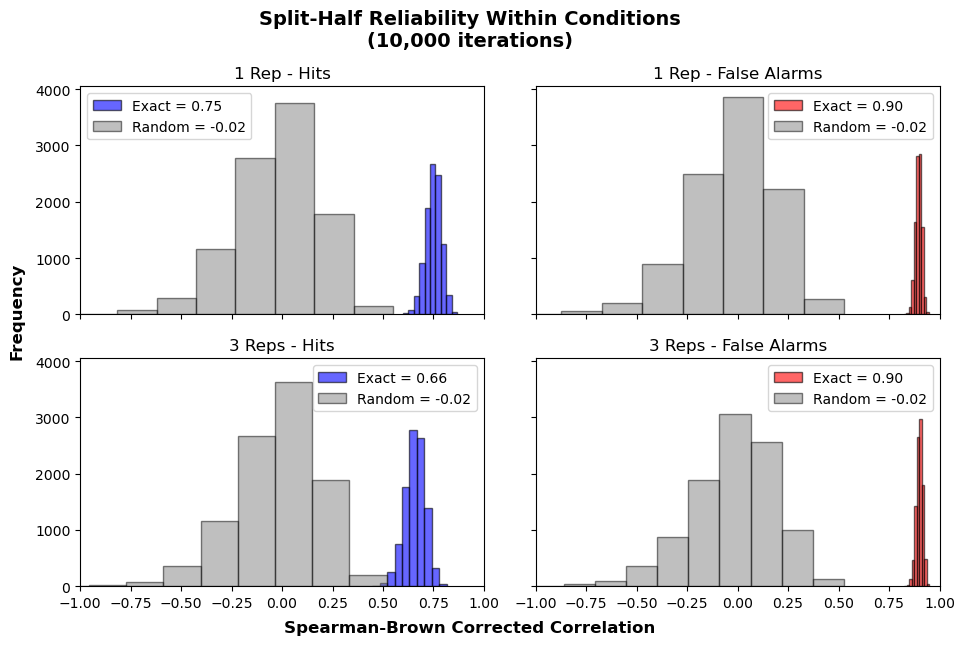

In [70]:
# Visualize WITHIN condition split-half reliability results

n_bins = 10

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

cond_map = {
    "1_Rep": "1 Rep",
    "3_Rep": "3 Reps"
}

# Loop over conditions and plot
for row, cond in enumerate(["1_Rep", "3_Rep"]):

    # ----- Hits -----
    axes[row, 0].hist(
        sh_corrs_hits['Exact'][cond],
        color='blue', alpha=0.6, edgecolor='black',
        bins=n_bins,
        label=f'Exact = {np.mean(sh_corrs_hits["Exact"][cond]):.2f}'
    )

    axes[row, 0].hist(
        sh_corrs_hits['Random'][cond],
        color='gray', alpha=0.5, edgecolor='black',
        bins=n_bins,
        label=f'Random = {np.mean(sh_corrs_hits["Random"][cond]):.2f}'
    )

    axes[row, 0].set_title(f'{cond_map[cond]} - Hits')
    axes[row, 0].legend()

    # ----- FA -----
    axes[row, 1].hist(
        sh_corrs_fa['Exact'][cond],
        color='red', alpha=0.6, edgecolor='black',
        bins=n_bins,
        label=f'Exact = {np.mean(sh_corrs_fa["Exact"][cond]):.2f}'
    )

    axes[row, 1].hist(
        sh_corrs_fa['Random'][cond],
        color='gray', alpha=0.5, edgecolor='black',
        bins=n_bins,
        label=f'Random = {np.mean(sh_corrs_fa["Random"][cond]):.2f}'
    )

    axes[row, 1].set_title(f'{cond_map[cond]} - False Alarms')
    axes[row, 1].legend()

# Global labels
for ax in axes.flatten():
    ax.set_xlim(-1, 1)

fig.text(0.5, 0.04, 'Spearman-Brown Corrected Correlation', ha='center', fontsize=12, fontweight='bold')
fig.text(0.04, 0.5, 'Frequency', va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.suptitle("Split-Half Reliability Within Conditions\n(10,000 iterations)", 
              ha = 'center',y = 0.93, fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95]) # leave space on the left - bottom - right - top
plt.show()

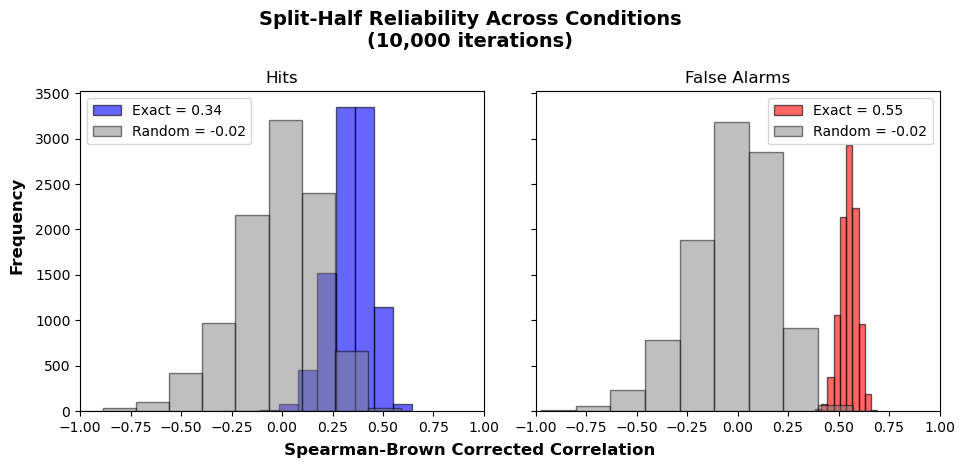

In [71]:
# Visualize ACROSS condition split-half reliability results

n_bins = 10

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
axes = axes.ravel()

cond_map = {
    "1_Rep": "1 Rep",
    "3_Rep": "3 Reps"
}

# Loop over conditions and plot


# ----- Hits -----
axes[0].hist(
    sh_corrs_hits_across['Exact'],
    color='blue', alpha=0.6, edgecolor='black',
    bins=n_bins,
    label=f'Exact = {np.mean(sh_corrs_hits_across["Exact"]):.2f}'
)

axes[0].hist(
    sh_corrs_hits_across['Random'],
    color='gray', alpha=0.5, edgecolor='black',
    bins=n_bins,
    label=f'Random = {np.mean(sh_corrs_hits_across["Random"]):.2f}'
)

axes[0].set_title(f'Hits')
axes[0].legend()

# ----- FA -----
axes[1].hist(
    sh_corrs_fa_across['Exact'],
    color='red', alpha=0.6, edgecolor='black',
    bins=n_bins,
    label=f'Exact = {np.mean(sh_corrs_fa_across["Exact"]):.2f}'
)

axes[1].hist(
    sh_corrs_fa_across['Random'],
    color='gray', alpha=0.5, edgecolor='black',
    bins=n_bins,
    label=f'Random = {np.mean(sh_corrs_fa_across["Random"]):.2f}'
)

axes[1].set_title(f'False Alarms')
axes[1].legend()

# Global labels
for ax in axes:
    ax.set_xlim(-1, 1)

fig.text(0.5, 0.04, 'Spearman-Brown Corrected Correlation', ha='center', fontsize=12, fontweight='bold')
fig.text(0.04, 0.5, 'Frequency', va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.suptitle("Split-Half Reliability Across Conditions\n(10,000 iterations)", 
              ha = 'center',y = 0.93, fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95]) # leave space on the left - bottom - right - top
plt.show()

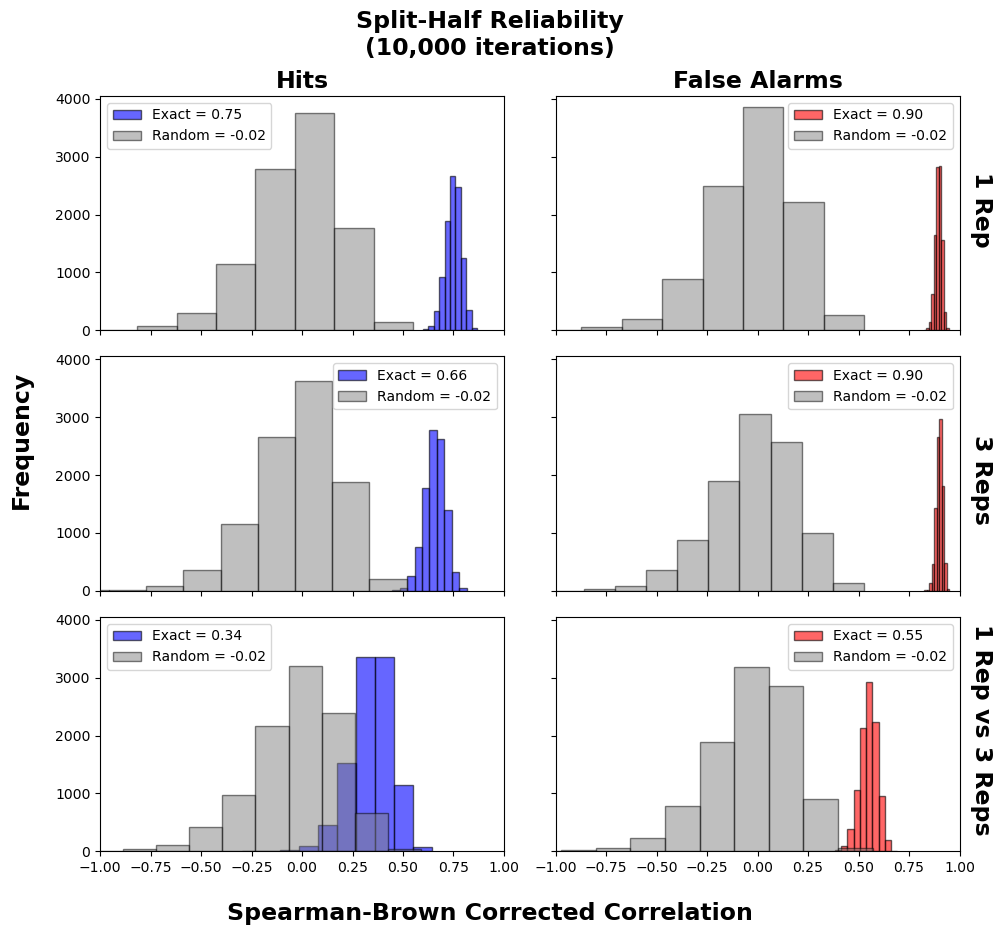

In [72]:
# Combined plot for within and across condition reliability
n_bins = 10

fig, axes = plt.subplots(3, 2, figsize=(10, 10), sharex=True, sharey=True)

cond_map = {
    "1_Rep": "1 Rep",
    "3_Rep": "3 Reps"
}

# ----- WITHIN CONDITION (rows 0 and 1) -----
for row, cond in enumerate(["1_Rep", "3_Rep"]):

    # Hits
    axes[row, 0].hist(
        sh_corrs_hits['Exact'][cond],
        color='blue', alpha=0.6, edgecolor='black',
        bins=n_bins,
        label=f'Exact = {np.mean(sh_corrs_hits["Exact"][cond]):.2f}'
    )

    axes[row, 0].hist(
        sh_corrs_hits['Random'][cond],
        color='gray', alpha=0.5, edgecolor='black',
        bins=n_bins,
        label=f'Random = {np.mean(sh_corrs_hits["Random"][cond]):.2f}'
    )

    axes[row, 0].legend()

    # False Alarms
    axes[row, 1].hist(
        sh_corrs_fa['Exact'][cond],
        color='red', alpha=0.6, edgecolor='black',
        bins=n_bins,
        label=f'Exact = {np.mean(sh_corrs_fa["Exact"][cond]):.2f}'
    )

    axes[row, 1].hist(
        sh_corrs_fa['Random'][cond],
        color='gray', alpha=0.5, edgecolor='black',
        bins=n_bins,
        label=f'Random = {np.mean(sh_corrs_fa["Random"][cond]):.2f}'
    )

    axes[row, 1].legend()


# ----- ACROSS CONDITION (row 2) -----

# Hits
axes[2, 0].hist(
    sh_corrs_hits_across['Exact'],
    color='blue', alpha=0.6, edgecolor='black',
    bins=n_bins,
    label=f'Exact = {np.mean(sh_corrs_hits_across["Exact"]):.2f}'
)

axes[2, 0].hist(
    sh_corrs_hits_across['Random'],
    color='gray', alpha=0.5, edgecolor='black',
    bins=n_bins,
    label=f'Random = {np.mean(sh_corrs_hits_across["Random"]):.2f}'
)

axes[2, 0].legend()


# False Alarms
axes[2, 1].hist(
    sh_corrs_fa_across['Exact'],
    color='red', alpha=0.6, edgecolor='black',
    bins=n_bins,
    label=f'Exact = {np.mean(sh_corrs_fa_across["Exact"]):.2f}'
)

axes[2, 1].hist(
    sh_corrs_fa_across['Random'],
    color='gray', alpha=0.5, edgecolor='black',
    bins=n_bins,
    label=f'Random = {np.mean(sh_corrs_fa_across["Random"]):.2f}'
)

axes[2, 1].legend()


# ----- Formatting -----
fs_title = 17
fs_ax_labels = 17
fs_grid_labels = 17

for ax in axes.flatten():
    ax.set_xlim(-1, 1)

fig.text(0.5, 0.02, 'Spearman-Brown Corrected Correlation',
         ha='center', fontsize=fs_ax_labels, fontweight='bold')

fig.text(0.02, 0.5, 'Frequency',
         va='center', rotation='vertical', fontsize=fs_ax_labels, fontweight='bold')

plt.suptitle(
    "Split-Half Reliability\n(10,000 iterations)",
    ha='center', y=0.93, fontsize=fs_title, fontweight='bold'
)

# Grid labels
cols = [f'{col}' for col in ['Hits', 'False Alarms']]
rows = [f'{row}' for row in ['1 Rep', '3 Reps', '1 Rep vs 3 Reps']]
row_positions = [0.73, 0.46, 0.21]  # vertical centers of the rows

for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=fs_grid_labels, fontweight='bold')


for y, row in zip(row_positions, rows):
    fig.text(0.98, y, row, va='center', ha='left',
             fontsize=fs_grid_labels, fontweight='bold', rotation=270)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

# H vs FA by distinct

In [73]:
# wider format with Hit and FA columns
df_by_item_wide = (df_by_item[['image_id','condition','category_name',
                                'distinct_rating','prop_yes',
                                'resp_type', 'distinct_type']]
                    .pivot(index = ['image_id', 'condition', 'category_name', 'distinct_rating', 'distinct_type'], 
                            columns='resp_type', values='prop_yes')
                    .reset_index()
                    )
df_by_item_wide

resp_type,image_id,condition,category_name,distinct_rating,distinct_type,FA,Hit
0,3,1_Rep,Andesite,3.17,Bottom,0.310606,0.524194
1,3,3_Rep,Andesite,3.17,Bottom,0.284314,0.500000
2,4,1_Rep,Andesite,3.18,Bottom,0.568182,0.556452
3,4,3_Rep,Andesite,3.18,Bottom,0.460784,0.447368
4,6,1_Rep,Andesite,3.17,Bottom,0.556452,0.734848
...,...,...,...,...,...,...,...
195,471,3_Rep,Shale,2.73,Bottom,0.421569,0.675439
196,472,1_Rep,Shale,2.55,Bottom,0.362903,0.598485
197,472,3_Rep,Shale,2.55,Bottom,0.254386,0.480392
198,476,1_Rep,Shale,2.48,Bottom,0.524194,0.704545


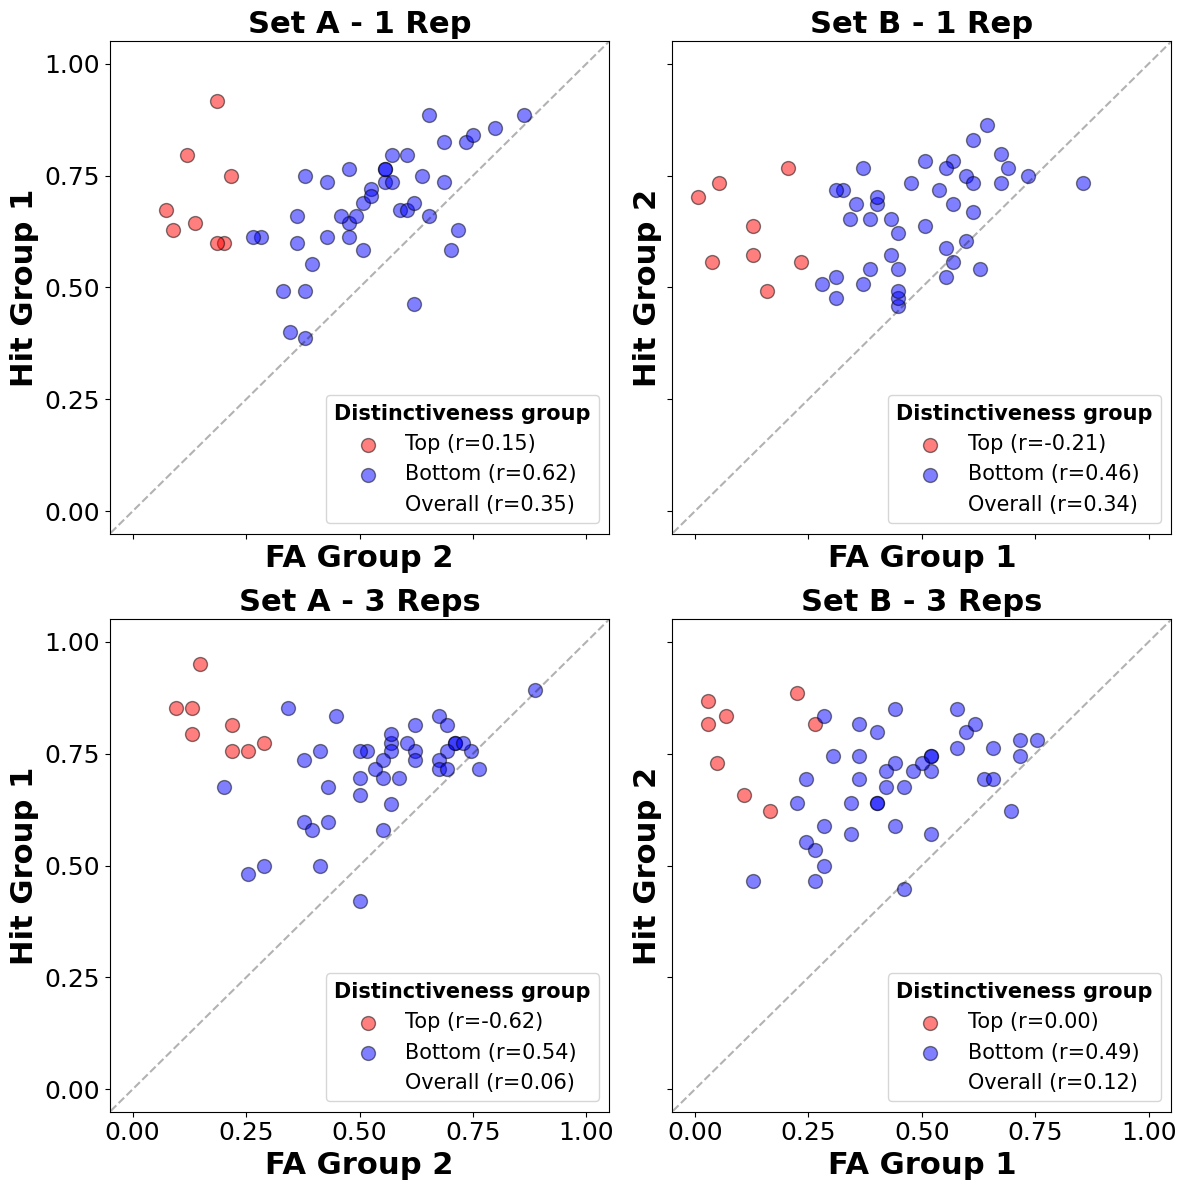

In [ ]:
# Plot: H vs FA correlations for each condition and distinctiveness group

fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True, sharex=True)

distinct_groups = ['Top', 'Bottom']
colors = ['red', 'blue']
conditions = ['1_Rep', '3_Rep']
condition_labels = ['1 Rep', '3 Reps']

fs = 22  # font size
fs_axes = 18
fs_legend = 15

for row_idx, (condition, condition_label) in enumerate(zip(conditions, condition_labels)):
    
    # For overall correlations
    x_all_left, y_all_left = [], []
    x_all_right, y_all_right = [], []
    
    # Left column: Group 2 FA vs Group 1 Hit
    for color, distinct in zip(colors, distinct_groups):
        x = df_by_item.loc[(df_by_item['distinct_type']==distinct) & 
                           (df_by_item['group']=='Group2') & 
                           (df_by_item['resp_type']=='FA') &
                           (df_by_item['condition']==condition), 'prop_yes'].reset_index(drop=True)
        y = df_by_item.loc[(df_by_item['distinct_type']==distinct) & 
                           (df_by_item['group']=='Group1') & 
                           (df_by_item['resp_type']=='Hit') &
                           (df_by_item['condition']==condition), 'prop_yes'].reset_index(drop=True)
        
        mask = ~(x.isna() | y.isna())
        r = x[mask].corr(y[mask])
        axes[row_idx, 0].scatter(x, y, alpha=0.5, edgecolor="k", color=color, s=100,
                                 label=f"{distinct} (r={r:.2f})")
        
        # accumulate for overall correlations
        x_all_left.append(x)
        y_all_left.append(y)
    
    # Calculate overall correlation for left column
    x_left = pd.concat(x_all_left, ignore_index=True)
    y_left = pd.concat(y_all_left, ignore_index=True)
    mask_left = ~(x_left.isna() | y_left.isna())
    r_left = x_left[mask_left].corr(y_left[mask_left])
    
    # Add dummy legend entry for overall correlation
    overall_handle_left = Line2D([], [], linestyle='None',
                                 label=f"Overall (r={r_left:.2f})")
    
    axes[row_idx, 0].plot([-0.1, 1.1], [-0.1, 1.1], 'k--', alpha=0.3)
    axes[row_idx, 0].set_xlabel('FA Group 2', fontweight='bold', fontsize=fs)
    axes[row_idx, 0].set_ylabel('Hit Group 1', fontweight='bold', fontsize=fs)
    axes[row_idx, 0].set_title(f'Set A - {condition_label}', fontsize=fs, fontweight='bold') # (Group 2 FA vs Group 1 Hit)
    axes[row_idx, 0].set_xlim(-0.05, 1.05)
    axes[row_idx, 0].set_ylim(-0.05, 1.05)
    axes[row_idx, 0].set_xticks(np.arange(0, 1.1, 0.25))
    axes[row_idx, 0].set_yticks(np.arange(0, 1.1, 0.25))
    axes[row_idx, 0].tick_params(axis='both', labelsize=fs_axes)
    
    # Rebuild legend with overall r included
    handles_left, labels_left = axes[row_idx, 0].get_legend_handles_labels()
    axes[row_idx, 0].legend(handles_left + [overall_handle_left], 
                            labels_left + [overall_handle_left.get_label()],
                            title="Distinctiveness group", 
                            fontsize=fs_legend,
                            title_fontsize=fs_legend,
                            loc='lower right')
    axes[row_idx, 0].get_legend().get_title().set_fontweight('bold')
    
    # Right column: Group 1 FA vs Group 2 Hit
    for color, distinct in zip(colors, distinct_groups):
        x_rev = df_by_item.loc[(df_by_item['distinct_type']==distinct) & 
                                (df_by_item['group']=='Group1') & 
                                (df_by_item['resp_type']=='FA') &
                                (df_by_item['condition']==condition), 'prop_yes'].reset_index(drop=True)
        y_rev = df_by_item.loc[(df_by_item['distinct_type']==distinct) & 
                                (df_by_item['group']=='Group2') & 
                                (df_by_item['resp_type']=='Hit') &
                                (df_by_item['condition']==condition), 'prop_yes'].reset_index(drop=True)
        
        mask_rev = ~(x_rev.isna() | y_rev.isna())
        r_rev = x_rev[mask_rev].corr(y_rev[mask_rev])
        axes[row_idx, 1].scatter(x_rev, y_rev, alpha=0.5, edgecolor="k", color=color, s=100,
                                 label=f"{distinct} (r={r_rev:.2f})")
        
        # accumulate for overall correlations
        x_all_right.append(x_rev)
        y_all_right.append(y_rev)
    
    # Calculate overall correlation for right column
    x_right = pd.concat(x_all_right, ignore_index=True)
    y_right = pd.concat(y_all_right, ignore_index=True)
    mask_right = ~(x_right.isna() | y_right.isna())
    r_right = x_right[mask_right].corr(y_right[mask_right])
    
    # Add dummy legend entry for overall correlation
    overall_handle_right = Line2D([], [], linestyle='None',
                                  label=f"Overall (r={r_right:.2f})")
    
    axes[row_idx, 1].plot([-0.1, 1.1], [-0.1, 1.1], 'k--', alpha=0.3)
    axes[row_idx, 1].set_xlabel('FA Group 1', fontweight='bold', fontsize=fs)
    axes[row_idx, 1].set_ylabel('Hit Group 2', fontweight='bold', fontsize=fs)
    axes[row_idx, 1].set_title(f'Set B - {condition_label}', fontsize=fs, fontweight='bold') # Group 1 FA vs Group 2 Hit
    axes[row_idx, 1].set_xlim(-0.05, 1.05)
    axes[row_idx, 1].set_ylim(-0.05, 1.05)
    axes[row_idx, 1].set_xticks(np.arange(0, 1.1, 0.25))
    axes[row_idx, 1].set_yticks(np.arange(0, 1.1, 0.25))
    axes[row_idx, 1].tick_params(axis='both', labelsize=fs_axes)
    
    # Rebuild legend with overall r included
    handles_right, labels_right = axes[row_idx, 1].get_legend_handles_labels()
    axes[row_idx, 1].legend(handles_right + [overall_handle_right], 
                            labels_right + [overall_handle_right.get_label()],
                            title="Distinctiveness group", 
                            fontsize=fs_legend,
                            title_fontsize=fs_legend,
                            loc='lower right')
    axes[row_idx, 1].get_legend().get_title().set_fontweight('bold')

plt.tight_layout()
plt.show()

In [155]:
# Exact correlations
# (use as a func because later we'll use it for predicted values as well)
def get_H_vs_FA_correlations(df_by_item, pred_col='prop_yes'):

    conditions = ['1_Rep', '3_Rep']
    condition_labels = ['1 Rep', '3 Reps']
    distinct_groups = ['Top', 'Bottom']
    panels = {
            "Set A (Group2 FA vs Group1 Hit)": ("Group2", "Group1"),
            "Set B (Group1 FA vs Group2 Hit)": ("Group1", "Group2"),
        }

    print(f"Column: {pred_col}")

    for condition, cond_label in zip(conditions, condition_labels):
        print(f"\n===== CONDITION: {cond_label} =====")

        for panel_name, (grA, grB) in panels.items():
            print(f"\n{panel_name}")

            x_all, y_all = [], []

            for distinct in distinct_groups:
                x = df_by_item.loc[
                    (df_by_item['distinct_type'] == distinct) &
                    (df_by_item['group'] == grA) &
                    (df_by_item['resp_type'] == 'FA') &
                    (df_by_item['condition'] == condition),
                    pred_col
                ].reset_index(drop=True)

                y = df_by_item.loc[
                    (df_by_item['distinct_type'] == distinct) &
                    (df_by_item['group'] == grB) &
                    (df_by_item['resp_type'] == 'Hit') &
                    (df_by_item['condition'] == condition),
                    pred_col
                ].reset_index(drop=True)

                mask = ~(x.isna() | y.isna())
                r, p = pearsonr(x[mask], y[mask])

                print(f"  {distinct}: r = {r:.2f}, p = {p:.3f}, n = {mask.sum()}")

                x_all.append(x)
                y_all.append(y)

            # Overall (collapsed over distinctiveness groups)
            x_all = pd.concat(x_all, ignore_index=True)
            y_all = pd.concat(y_all, ignore_index=True)
            mask_all = ~(x_all.isna() | y_all.isna())
            r_all, p_all = pearsonr(x_all[mask_all], y_all[mask_all])

            print(f"  Overall: r = {r_all:.2f}, p = {p_all:.3f}, n = {mask_all.sum()}")

In [156]:
get_H_vs_FA_correlations(df_by_item, pred_col='prop_yes')

Column: prop_yes

===== CONDITION: 1 Rep =====

Set A (Group2 FA vs Group1 Hit)
  Top: r = 0.15, p = 0.716, n = 8
  Bottom: r = 0.62, p = 0.000, n = 42
  Overall: r = 0.35, p = 0.014, n = 50

Set B (Group1 FA vs Group2 Hit)
  Top: r = -0.21, p = 0.616, n = 8
  Bottom: r = 0.46, p = 0.002, n = 42
  Overall: r = 0.34, p = 0.016, n = 50

===== CONDITION: 3 Reps =====

Set A (Group2 FA vs Group1 Hit)
  Top: r = -0.62, p = 0.100, n = 8
  Bottom: r = 0.54, p = 0.000, n = 42
  Overall: r = 0.06, p = 0.694, n = 50

Set B (Group1 FA vs Group2 Hit)
  Top: r = 0.00, p = 0.995, n = 8
  Bottom: r = 0.49, p = 0.001, n = 42
  Overall: r = 0.12, p = 0.409, n = 50


# Models

## Hybrid-Similarity Model

Hybrid-Similarity Model. 

$$P( 'Old' | i) = P( 'Old' | F_i)$$

Where $P( 'Old' | F_i) = \frac{F_i}{F_i + k}$, where $k$ is a free parameter. 

$F_i = \sum_{j = 1}^{J} S_{ij}$, where $S_{ij}$ is the similarity between test item $i$ to all study items $j$. 

$S_{ij}$ is based on 
1. The distances between items $i$ and $j$ in the similarity space: $S_{ij} = e^{-c \times D_{ij}}$ ($c$ is a free parameter, $D_{ij} = \sqrt{ \sum_{m=1}^M (x_{im} - x_{jm})^2 } $ is the distance in the $M$-dimensional space)
2. And on the distinctivenes ratings: $S_{ii} = e^{\beta \times d_i} \times e^{-c \times D_{ij}} = e^{\beta \times d_i} \times 1 = e^{\beta \times d_i}$, if $i$ is an old item and $S_{ij} = e^{\alpha \times d_i} \times e^{-c \times D_{ij}}$, if $i$ is a new item, where $\alpha$ and $\beta$ are free parameters, and $d_i$ is the distinctiveness rating of item $i$.

In [ ]:
# Load MDS solution
mds_solution = pd.read_csv('https://raw.githubusercontent.com/DaniilAzarov123/Rocks_Database/main/info/Rocks480_MDS8_solution.csv')
mds_solution

,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,image_id
0,-2.757,-1.594,1.052,0.768,1.343,1.711,1.795,0.809,1
1,2.001,-0.754,1.405,-1.382,-1.384,0.976,-0.067,1.972,2
2,0.261,-0.508,-2.962,-0.608,0.009,-0.191,2.720,-1.224,3
3,0.382,-0.027,-0.148,-1.899,-1.948,1.862,0.968,0.986,4
4,0.288,2.013,-1.102,-1.285,0.344,-0.009,2.696,-0.174,5
...,...,...,...,...,...,...,...,...,...
475,0.749,-3.021,-1.908,-1.689,-0.493,4.441,-0.122,1.618,476
476,-0.054,-2.743,-1.435,-2.903,0.315,3.161,1.833,1.288,477
477,0.007,-2.077,-4.012,-1.633,-0.366,2.558,4.210,-0.060,478
478,0.177,-2.520,-2.293,-1.216,0.545,0.805,2.302,0.629,479


In [77]:
# study lists
study_list_gr1 = np.sort(filtered_data_memory.loc[filtered_data_memory['group']=='Group1', 'image_id'].unique())
study_list_gr2 = np.sort(filtered_data_memory.loc[filtered_data_memory['group']=='Group2', 'image_id'].unique())

# test list
test_list = np.sort(filtered_data_test['image_id'].unique())

In [80]:
# Calculate distances

# Step 1: Extract the MDS coordinates (first 8 columns)
# Make sure image_id is set as the index for easy lookup
mds_coords = mds_solution.set_index('image_id').iloc[:, :8]

# ------------- Group 1 ----------

# Step 2: Get row and column names from dist_mat_gr1
row_ids = test_list 
col_ids = study_list_gr1

# Step 3: Extract MDS coordinates for rows and columns
# This creates matrices where each row/column corresponds to the image_ids
mds_rows = mds_coords.loc[row_ids].values  # Shape: (240, 8)
mds_cols = mds_coords.loc[col_ids].values  # Shape: (120, 8)

# Step 4: Calculate Euclidean distances efficiently
# Using broadcasting: expand dimensions to compute all pairwise distances at once
# mds_rows[:, np.newaxis, :] has shape (240, 1, 8)
# mds_cols[np.newaxis, :, :] has shape (1, 120, 8)
# The difference has shape (240, 120, 8)
diff = mds_rows[:, np.newaxis, :] - mds_cols[np.newaxis, :, :]

# Calculate Euclidean distance: sqrt of sum of squared differences
distances = np.sqrt(np.sum(diff**2, axis=2))

# Step 5: Create a DataFrame with the same structure as dist_mat_gr1
dist_mat_gr1 = pd.DataFrame(
    distances,
    index=row_ids,
    columns=col_ids
)

# ------------- Group 2 ----------

# Step 2: Get row and column names from dist_mat_gr1
row_ids = test_list 
col_ids = study_list_gr2

# Step 3: Extract MDS coordinates for rows and columns
# This creates matrices where each row/column corresponds to the image_ids
mds_rows = mds_coords.loc[row_ids].values  # Shape: (240, 8)
mds_cols = mds_coords.loc[col_ids].values  # Shape: (120, 8)

# Step 4: Calculate Euclidean distances efficiently
# Using broadcasting: expand dimensions to compute all pairwise distances at once
# mds_rows[:, np.newaxis, :] has shape (240, 1, 8)
# mds_cols[np.newaxis, :, :] has shape (1, 120, 8)
# The difference has shape (240, 120, 8)
diff = mds_rows[:, np.newaxis, :] - mds_cols[np.newaxis, :, :]

# Calculate Euclidean distance: sqrt of sum of squared differences
distances = np.sqrt(np.sum(diff**2, axis=2))

# Step 5: Create a DataFrame with the same structure as dist_mat_gr1
dist_mat_gr2 = pd.DataFrame(
    distances,
    index=row_ids,
    columns=col_ids
)

In `dist_mat_gr1` (100x50) and `dist_mat_gr2` (100x50), each row is each test item (they are the **same** accross two matrices), and each column is each study item (they are **different** accross matrices).

In [81]:
# Dicionary comprehension: {image_id: distinctiveness}
distinctiveness_image_id = df_by_item.set_index('image_id')['distinct_rating'].to_dict()
list(distinctiveness_image_id.items())[:5] # first 5 items

[(3, 3.17), (4, 3.18), (6, 3.17), (8, 1.95), (9, 2.49)]

In [84]:
# Transform similarities based on distinctiveness ratings:
# increased self-similarity for more distinctive items and decreased similarity to other items for more distinctive items
def transform_similarity_matrix(alpha, beta, 
                                similarity_matrix, 
                                distinctiveness_dict = distinctiveness_image_id):
    # Create a copy to avoid modifying the original
    transformed = similarity_matrix.copy()
    
    # Iterate through each row
    for row_id in transformed.index:
        # Get distinctiveness for this row's image
        distinct_i = distinctiveness_dict[row_id]
        
        # Iterate through each column
        for col_id in transformed.columns:
            s_ij = similarity_matrix.loc[row_id, col_id]
            
            if row_id == col_id:
                # Self-similarity case: exp(beta * distinct_i)
                # Since s_ii = 1
                transformed.loc[row_id, col_id] = np.exp(beta * distinct_i)
            else:
                # Similarity between different items (item i and item j) case
                # s_ij * exp(-alpha * distinct_i)
                transformed.loc[row_id, col_id] = np.exp(-alpha * distinct_i) * s_ij
    
    return transformed

In [83]:
# For NegLogLikelihood calculation
filtered_data_test['responded_old'] = np.where(filtered_data_test['response'] == "l", 1, 0)
filtered_data_test

,trial_index,subject_id,group,condition,task,item_type,response,correct_response,cor_ans,rt,category_name,category,broad_category,image_png,image_id,distinct_rating,distinct_type,good_subj,resp_type,responded_old
0,311,91746,Group2,3_Rep,test_phase,Target,l,l,True,1776.0,Gneiss,13,M,M_Gneiss_15.png,207,3.11,Bottom,True,Hit,1
1,313,91746,Group2,3_Rep,test_phase,Target,l,l,True,767.0,Rock Salt,28,S,S_Rock Salt_13.png,445,7.58,Top,True,Hit,1
2,315,91746,Group2,3_Rep,test_phase,Target,l,l,True,779.0,Pegmatite,7,I,I_Pegmatite_03.png,99,7.24,Top,True,Hit,1
3,317,91746,Group2,3_Rep,test_phase,Target,l,l,True,805.0,Gneiss,13,M,M_Gneiss_10.png,202,3.09,Bottom,True,Hit,1
4,319,91746,Group2,3_Rep,test_phase,Foil,a,a,True,924.0,Rhyolite,10,I,I_Rhyolite_16.png,160,2.19,Bottom,True,CR,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23195,501,92625,Group2,3_Rep,test_phase,Foil,a,a,True,1088.0,Obsidian,6,I,I_Obsidian_05.png,85,7.32,Top,True,CR,0
23196,503,92625,Group2,3_Rep,test_phase,Target,l,l,True,815.0,Gneiss,13,M,M_Gneiss_10.png,202,3.09,Bottom,True,Hit,1
23197,505,92625,Group2,3_Rep,test_phase,Foil,l,a,False,1000.0,Marble,15,M,M_Marble_04.png,228,3.15,Bottom,True,FA,1
23198,507,92625,Group2,3_Rep,test_phase,Target,l,l,True,683.0,Gneiss,13,M,M_Gneiss_14.png,206,3.41,Bottom,True,Hit,1


In [90]:
# Different parameters for different groups

def HS_model(parameters,
             data, 
             distances_mats_list = [dist_mat_gr1, dist_mat_gr2], 
             distinctiveness_dict = distinctiveness_image_id):
    # parameters
    c, alpha, beta, k = parameters
    
    # get group name
    group = data['group'].unique()[0]
    groupN = 0 if group == 'Group1' else 1
    
    # Distances matrices
    distances_mat = distances_mats_list[groupN]
    
    # (Raw) Similarity matrices
    similarity_mat = np.exp(-c * distances_mat)
    
    # Transform similarities based on distinctiveness ratings
    similarity_mat_transformed = transform_similarity_matrix(alpha=alpha, beta=beta, 
                                                             similarity_matrix=similarity_mat, distinctiveness_dict=distinctiveness_dict)
    
    # Summed similarities (familiarity) for each item
    familiarity = np.sum(similarity_mat_transformed, axis=1)
    
    # Expand familiarities for each subject (to match the test data)
    familiarities = []
    for _, row in data.iterrows():
        image_id = row['image_id']
        familiarity_i_subj = familiarity.loc[familiarity.index == image_id]        
        familiarities.append(familiarity_i_subj.values[0] if not familiarity_i_subj.empty else np.nan)
    
    # Predicted proportions of "Old" responses ("Yes")
    predictions = [fam / (fam + k) for fam in familiarities]
    
    return predictions    

## Recollection Model

Recollection Model. 

$$P( 'Old' | i) = P_{recollect} + (1 - P_{recollect}) \times P( 'Old' | F_i)$$

Where $P( 'Old' | F_i) = \frac{F_i}{F_i + k}$, where $k$ is a free parameter. 

$F_i = \sum_{j = 1}^{J} S_{ij}$, where $S_{ij}$ is the similarity between test item $i$ to all study items $j$. 

$S_{ij}$ is based on 
1. The distances between items $i$ and $j$ in the similarity space: $S_{ij} = e^{-c \times D}$ ($c$ is a free parameter, $D = \sqrt{ \sum_{m=1}^M (x_{im} - x_{jm})^2 } $ is the distance in the $M$-dimensional space)
2. And on the distinctivenes ratings: $S_{ii} = e^{\beta \times d_i}$, if $i$ is an old item and $S_{ij} = e^{- \alpha \times d_i}$, if $i$ is a new item, where $\alpha$ and $\beta$ are free parameters, and $d_i$ is the distinctiveness rating of item $i$.

The recollection part is $P_{recollect} = P_{sample} \times P_{recover}$ where: 

- $P_{sample} = \frac{ S_{ii} }{ \sum_{j} S_{ij}} = \frac{ e^{\beta \times d_i} }{ F_i}$
- $P_{recover} = \frac{S_{ii}}{S_{ii} + k_{recollect}} = \frac{e^{\beta \times d_i}}{S_{ii} + k_{recollect}}$, where $k_{recollect}$ is a free parameter.



In [83]:
# # Different parameters for different groups

# def recollection_model(parameters, 
#                           data, 
#                           distances_mats_list = [dist_mat_gr1, dist_mat_gr2], 
#                           distinctiveness_dict = distinctiveness_image_id):
#     """
#     Recollection-Familiarity model to predict P("Yes" | Item i) based on distances in the similarity space and their distinctiveness.
    
#     Recollection component added is based on the self-similarity values.
    
#     Parameters:
#     -----------
#     parameters : list or np.ndarray
#         List of parameters [c, alpha, beta, k, k_recollect]
#     data : pd.DataFrame
#         Long DataFrame with columns: 'group', 'image_id'
#     distances_mat : list of pd.DataFrame
#         A list of two distance matrices for Group 1 and Group 2 (pd.DataFrame)
#     distinctiveness_dict : dict
#         Dictionary mapping image_id to distinctiveness rating
    
#     Returns:
#     --------
#     predictions : list
#         List of predicted probabilities P(Old|Item) for each row in data
#     """
#     # parameters
#     c, alpha, beta, k, k_recollect = parameters
    
#     # get group name
#     group = data['group'].unique()[0]
#     groupN = 0 if group == 'Group1' else 1
    
#     # Distances matrices
#     distances_mat = distances_mats_list[groupN]
    
#     # (Raw) Similarity matrices
#     similarity_mat = calculate_similarity_matrix(distances_mat, c)
    
#     # Transformed Similarity matrices
#     similarity_mat_transformed = transform_similarity_matrix(alpha=alpha, beta=beta, 
#                                                                  similarity_matrix=similarity_mat, 
#                                                                  distinctiveness_dict=distinctiveness_dict)
    
#     # Familiarity values for groups (aka summed similarities)
#     familiarity = np.sum(similarity_mat_transformed, axis=1)
    
#     # Extract self-similarities
#     self_similarities = []
#     for i in range(similarity_mat_transformed.shape[0]):
#         is_old = np.sum(similarity_mat_transformed.index[i] == similarity_mat_transformed.columns) > 0
#         idx = similarity_mat_transformed.index[i]
#         if is_old:
#             self_similarities.append(similarity_mat_transformed.loc[idx, idx]) # self-match value
#         else:
#             self_similarities.append(0) # no recollection
    
#     # Calclulate recollection components:
#     p_sample = np.array(self_similarities) / familiarity.values
#     p_recover = np.array(self_similarities) / (np.array(self_similarities) + k_recollect)
#     p_recollect = p_sample * p_recover
#     # make into a pd.Series (with index)
#     p_recollect = pd.Series(p_recollect, index=similarity_mat_transformed.index)
    
#     # iterate over rows in filtered_data_test to get familiarity and recollections
#     # for each item and subject in the right order
#     familiarities = []
#     recollections = []
#     for _, row in data.iterrows():
#         image_id = row['image_id']
#         familiarity_i_subj = familiarity.loc[familiarity.index == image_id]        
#         familiarities.append(familiarity_i_subj.values[0] if not familiarity_i_subj.empty else np.nan)
#         recollection_i_subj = p_recollect.loc[p_recollect.index == image_id]
#         recollections.append(recollection_i_subj.values[0] if not recollection_i_subj.empty else np.nan)
    
#     # Predicted proportions of "Old" responses ("Yes"): p(yes)
#     predictions = [rec + (1 - rec) * ( fam / (fam + k) ) for fam, rec in zip(familiarities,recollections)]
    
#     return predictions    

# Optimization

In [92]:
def NegLogLikelihood(parameters,
                     model_function,
                     df_observed = filtered_data_test.loc[filtered_data_test["group"]=="Group1"], 
                     distances_mats_list = [dist_mat_gr1, dist_mat_gr2], 
                     distinctiveness_dict = distinctiveness_image_id):
    # Get model predictions
    predicted = model_function(parameters, df_observed, distances_mats_list, distinctiveness_dict)
    
    # Merge observed and predicted data
    df_merged = df_observed.copy()
    df_merged['prop_yes_pred'] = predicted
    
    # Avoid log(0) by clipping predicted probabilities
    epsilon = 1e-10
    df_merged['prop_yes_pred'] = df_merged['prop_yes_pred'].clip(epsilon, 1 - epsilon)
    
    # Calculate log-likelihood for each observation
    df_merged['log_likelihood'] = (
        df_merged['responded_old'] * np.log(df_merged['prop_yes_pred']) +
        (1 - df_merged['responded_old']) * np.log(1 - df_merged['prop_yes_pred'])
                                   )
    # Sum log-likelihoods and return negative value
    neg_log_likelihood = -df_merged['log_likelihood'].sum()
    
    return neg_log_likelihood

In [93]:
# Store optimization results in a dictionary
# for each model, condition and group
optimization_result = {}

## HS-model optim

In [95]:
initial_params = [1, 1, 1, 1]  # c, alpha, beta, k

# Set bounds for parameters (optional but recommended)
bounds = [
    (None, None),      # c >= 0
    (None, None),      # alpha >= 0
    (None, None),      # beta >= 0
    (None, None)      # k >= 0
]

# store optimization results in a dictionary
model = 'HS_model'
optimization_result[model] = {}
groups = ['Group1', 'Group2']
conditions = ['1_Rep', '3_Rep']

# Loop through each group and condition
for condition in conditions:
    for group in groups:
        print(f"Optimizing for {condition} - {group}...")
        
        # Filter observed data for this group and condition
        df_observed = filtered_data_test.loc[
            (filtered_data_test["group"] == group) &
            (filtered_data_test["condition"] == condition)
        ]
        
        # Optimize parameters using Nelder-Mead method
        result = minimize(
            NegLogLikelihood, 
            initial_params, 
            args=(HS_model, df_observed, [dist_mat_gr1, dist_mat_gr2], distinctiveness_image_id), 
            method='Nelder-Mead',
            bounds=bounds,
            options={'maxiter': 1000, 'disp': True}
        )
        
        # Store results
        optimization_result[model][(group, condition)] = result
        
        print(f"Best parameters for {condition} - {group}: {result.x}")
        print(f"Negative Log-Likelihood: {result.fun}\n")
        
        # Flag if optimization did not converge
        if not result.success:
            print("=============== Attention: Optimization did not converge! ===============\n")

Optimizing for 1_Rep - Group1...
Optimization terminated successfully.
         Current function value: 4100.127459
         Iterations: 164
         Function evaluations: 282
Best parameters for 1_Rep - Group1: [0.52126188 0.19650687 0.22099545 2.11614714]
Negative Log-Likelihood: 4100.127459279036

Optimizing for 1_Rep - Group2...
Optimization terminated successfully.
         Current function value: 3944.543545
         Iterations: 225
         Function evaluations: 371
Best parameters for 1_Rep - Group2: [0.76401335 0.03087946 0.088326   1.16729782]
Negative Log-Likelihood: 3944.543544977685

Optimizing for 3_Rep - Group1...
Optimization terminated successfully.
         Current function value: 3017.787846
         Iterations: 186
         Function evaluations: 321
Best parameters for 3_Rep - Group1: [0.71906807 0.09949254 0.26333252 1.4370371 ]
Negative Log-Likelihood: 3017.787846350463

Optimizing for 3_Rep - Group2...
Optimization terminated successfully.
         Current functi

In [130]:
# Best parameters:
print("Best parameters:\n")
param_names = ['c', 'alpha', 'beta', 'k']
for gr_cond, parameters in zip(optimization_result['HS_model'].keys(), 
                               list(optimization_result['HS_model'].values())
                               ):
    params = parameters.x
    print(f"{gr_cond[1]} - {gr_cond[0]}:\n {', '.join([p + ': ' + str(round(p_val, 3)) for p, p_val in zip(param_names, params)])}\n")

Best parameters:

1_Rep - Group1:
 c: 0.521, alpha: 0.197, beta: 0.221, k: 2.116

1_Rep - Group2:
 c: 0.764, alpha: 0.031, beta: 0.088, k: 1.167

3_Rep - Group1:
 c: 0.719, alpha: 0.099, beta: 0.263, k: 1.437

3_Rep - Group2:
 c: 0.595, alpha: 0.109, beta: 0.254, k: 1.703



In [131]:
# Predict data using optimized parameters
filtered_data_test['HS_preds'] = np.nan
groups = ['Group1', 'Group2']
conditions = ['1_Rep', '3_Rep']
model = 'HS_model'
for condition in conditions:
    for group in groups:
        print(f"Predicting for {condition} - {group}...")
        
        # Get optimized parameters for this group and condition
        result = optimization_result[model][(group, condition)]
        optimal_params = result.x
        
        # Filter data for this group and condition
        data_subset = filtered_data_test.loc[
            (filtered_data_test["group"] == group) &
            (filtered_data_test["condition"] == condition)
        ]
        
        # Get predictions
        predictions = HS_model(optimal_params, data_subset, [dist_mat_gr1, dist_mat_gr2], distinctiveness_image_id)
        
        # Store predictions in the main DataFrame
        filtered_data_test.loc[
            (filtered_data_test["group"] == group) &
            (filtered_data_test["condition"] == condition),
            'HS_preds'
        ] = predictions

Predicting for 1_Rep - Group1...
Predicting for 1_Rep - Group2...
Predicting for 3_Rep - Group1...
Predicting for 3_Rep - Group2...


In [133]:
# Add predictions to df_by_item (mean per item)
df_by_item = pd.merge(df_by_item, 
                      pd.pivot_table(filtered_data_test, 
                                     index=['image_id','group', 'condition'], 
                                     values='HS_preds', 
                                     aggfunc='mean',
                                     observed=True).reset_index(),
                      on=['image_id', 'group', 'condition']
                      )
df_by_item

,image_id,condition,group,n_subj,n_yes,item_type,category_name,distinct_rating,distinct_type,prop_yes,resp_type,HS_preds
0,3,1_Rep,Group1,65,20,Foil,Andesite,3.17,Bottom,0.310606,FA,0.500815
1,3,1_Rep,Group2,61,32,Target,Andesite,3.17,Bottom,0.524194,Hit,0.658036
2,3,3_Rep,Group1,50,14,Foil,Andesite,3.17,Bottom,0.284314,FA,0.469553
3,3,3_Rep,Group2,56,28,Target,Andesite,3.17,Bottom,0.500000,Hit,0.687004
4,4,1_Rep,Group1,65,37,Foil,Andesite,3.18,Bottom,0.568182,FA,0.485232
...,...,...,...,...,...,...,...,...,...,...,...,...
395,472,3_Rep,Group2,56,14,Foil,Shale,2.55,Bottom,0.254386,FA,0.509505
396,476,1_Rep,Group1,65,46,Target,Shale,2.48,Bottom,0.704545,Hit,0.651839
397,476,1_Rep,Group2,61,32,Foil,Shale,2.48,Bottom,0.524194,FA,0.541247
398,476,3_Rep,Group1,50,40,Target,Shale,2.48,Bottom,0.794118,Hit,0.685102


## Base model optim

In [134]:
initial_params_reduced = [1, 1]  # c, k (alpha=0, beta=0 fixed)

# store optimization results in a dictionary
model = 'Base_model'
optimization_result[model] = {}
groups = ['Group1', 'Group2']
conditions = ['1_Rep', '3_Rep']

# Loop through each group and condition
for condition in conditions:
    for group in groups:
        print(f"Optimizing for {condition} - {group}...")
        
        # Filter observed data for this group and condition
        df_observed = filtered_data_test.loc[
            (filtered_data_test["group"] == group) &
            (filtered_data_test["condition"] == condition)
        ]
        
        # Optimize parameters using Nelder-Mead method (alpha=0, beta=0 fixed)
        result = minimize(
            lambda params, *args: NegLogLikelihood([params[0], 0, 0, params[1]], *args),
            initial_params_reduced, 
            args=(HS_model, df_observed, [dist_mat_gr1, dist_mat_gr2], distinctiveness_image_id), 
            method='Nelder-Mead',
            options={'maxiter': 1000, 'disp': True}
        )
        
        # Store results
        optimization_result[model][(group, condition)] = result
        
        print(f"Best parameters for {condition} - {group}: {result.x}")
        print(f"Negative Log-Likelihood: {result.fun}\n")
        
        # Flag if optimization did not converge
        if not result.success:
            print("=============== Attention: Optimization did not converge! ===============\n")


Optimizing for 1_Rep - Group1...
Optimization terminated successfully.
         Current function value: 4146.297897
         Iterations: 33
         Function evaluations: 65
Best parameters for 1_Rep - Group1: [0.87812469 0.84895755]
Negative Log-Likelihood: 4146.297897091899

Optimizing for 1_Rep - Group2...
Optimization terminated successfully.
         Current function value: 3950.721217
         Iterations: 39
         Function evaluations: 76
Best parameters for 1_Rep - Group2: [0.87350799 0.82952447]
Negative Log-Likelihood: 3950.721216924225

Optimizing for 3_Rep - Group1...
Optimization terminated successfully.
         Current function value: 3063.068867
         Iterations: 40
         Function evaluations: 76
Best parameters for 3_Rep - Group1: [1.03978503 0.56057381]
Negative Log-Likelihood: 3063.0688665168345

Optimizing for 3_Rep - Group2...
Optimization terminated successfully.
         Current function value: 3567.287381
         Iterations: 38
         Function evaluat

In [135]:
# Best parameters:
print("Best parameters:\n")
param_names = ['c', 'k']
for gr_cond, parameters in zip(optimization_result['Base_model'].keys(), 
                               list(optimization_result['Base_model'].values())
                               ):
    params = parameters.x
    print(f"{gr_cond[1]} - {gr_cond[0]}:\n {', '.join([p + ': ' + str(round(p_val, 3)) for p, p_val in zip(param_names, params)])}\n")

Best parameters:

1_Rep - Group1:
 c: 0.878, k: 0.849

1_Rep - Group2:
 c: 0.874, k: 0.83

3_Rep - Group1:
 c: 1.04, k: 0.561

3_Rep - Group2:
 c: 0.912, k: 0.642



In [136]:
# Predict data using optimized parameters
filtered_data_test['Base_preds'] = np.nan
groups = ['Group1', 'Group2']
conditions = ['1_Rep', '3_Rep']
model = 'Base_model'
for condition in conditions:
    for group in groups:
        print(f"Predicting for {condition} - {group}...")
        
        # Get optimized parameters for this group and condition
        result = optimization_result[model][(group, condition)]
        optimal_params_reduced = result.x
        
        # Reconstruct full parameter vector with alpha=0, beta=0
        optimal_params_full = [optimal_params_reduced[0], 0, 0, optimal_params_reduced[1]]
        
        # Filter data for this group and condition
        data_subset = filtered_data_test.loc[
            (filtered_data_test["group"] == group) &
            (filtered_data_test["condition"] == condition)
        ]
        
        # Get predictions
        predictions = HS_model(optimal_params_full, data_subset, [dist_mat_gr1, dist_mat_gr2], distinctiveness_image_id)
        
        # Store predictions in the main DataFrame
        filtered_data_test.loc[
            (filtered_data_test["group"] == group) &
            (filtered_data_test["condition"] == condition),
            'Base_preds'
        ] = predictions

Predicting for 1_Rep - Group1...
Predicting for 1_Rep - Group2...
Predicting for 3_Rep - Group1...
Predicting for 3_Rep - Group2...


In [137]:
# Add predictions to df_by_item (mean per item)
df_by_item = pd.merge(df_by_item, 
                      pd.pivot_table(filtered_data_test, 
                                     index=['image_id','group', 'condition'], 
                                     values='Base_preds', 
                                     aggfunc='mean',
                                     observed=True).reset_index(),
                      on=['image_id', 'group', 'condition']
                      )
df_by_item

,image_id,condition,group,n_subj,n_yes,item_type,category_name,distinct_rating,distinct_type,prop_yes,resp_type,HS_preds,Base_preds
0,3,1_Rep,Group1,65,20,Foil,Andesite,3.17,Bottom,0.310606,FA,0.500815,0.526467
1,3,1_Rep,Group2,61,32,Target,Andesite,3.17,Bottom,0.524194,Hit,0.658036,0.666133
2,3,3_Rep,Group1,50,14,Foil,Andesite,3.17,Bottom,0.284314,FA,0.469553,0.483219
3,3,3_Rep,Group2,56,28,Target,Andesite,3.17,Bottom,0.500000,Hit,0.687004,0.708823
4,4,1_Rep,Group1,65,37,Foil,Andesite,3.18,Bottom,0.568182,FA,0.485232,0.456106
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,472,3_Rep,Group2,56,14,Foil,Shale,2.55,Bottom,0.254386,FA,0.509505,0.490361
396,476,1_Rep,Group1,65,46,Target,Shale,2.48,Bottom,0.704545,Hit,0.651839,0.680382
397,476,1_Rep,Group2,61,32,Foil,Shale,2.48,Bottom,0.524194,FA,0.541247,0.542546
398,476,3_Rep,Group1,50,40,Target,Shale,2.48,Bottom,0.794118,Hit,0.685102,0.718601


# Visualization

## Pred vs Real

### HS model

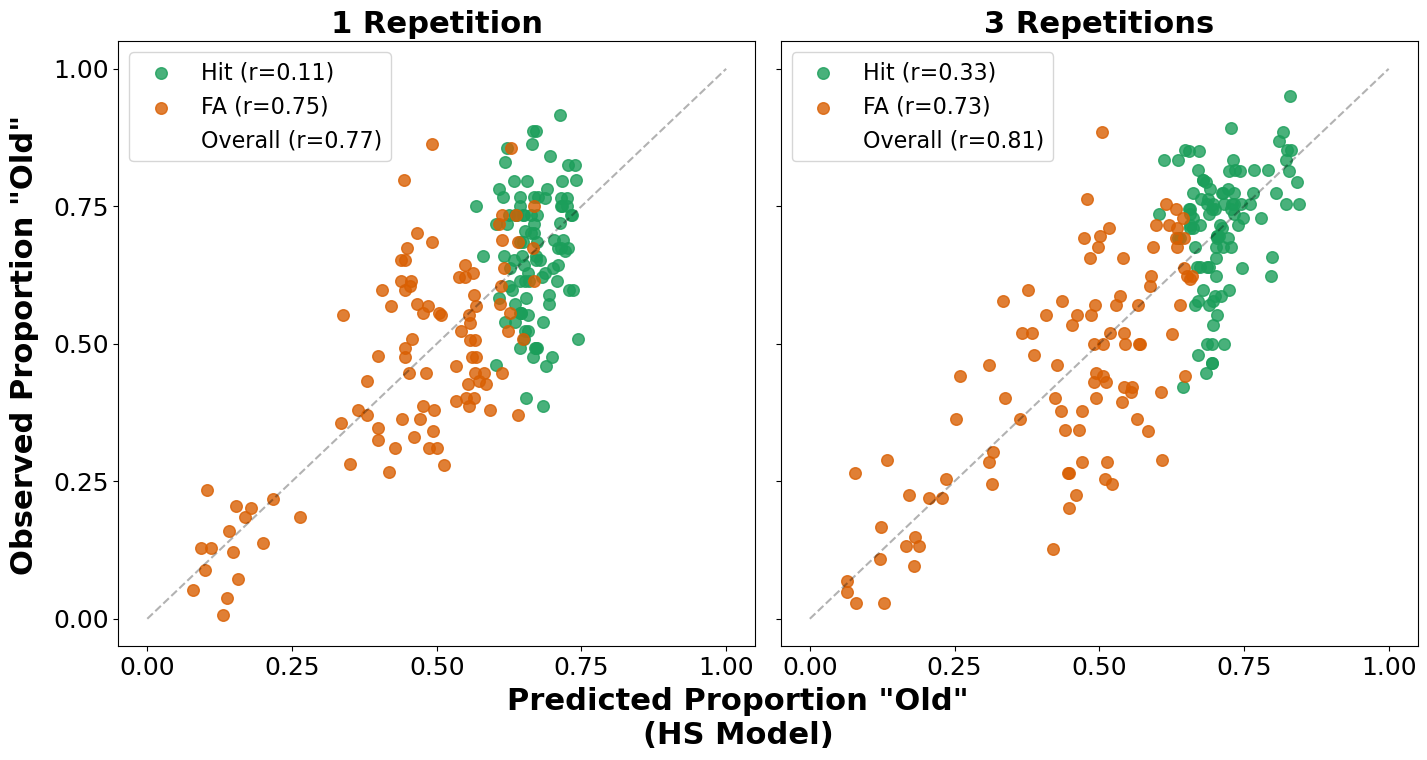

In [187]:

# Observed vs Predicted
fs = 22
fs_axes = 18
fs_legend = 16

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.ravel()  # flatten to 1D array
conditions = ['1_Rep', '3_Rep']
condition_labels = ['1 Repetition', '3 Repetitions']
for idx, (condition, condition_label) in enumerate(zip(conditions, condition_labels)):
    df = df_by_item[df_by_item['condition'] == condition]
    # Correlations by response type
    cors = df.groupby('resp_type', observed=True, group_keys=False).apply(
        lambda x: pd.Series(
            stats.pearsonr(x['prop_yes'], x['HS_preds']),
            index=['r', 'p_value']
        ),
        include_groups=False
        ).reset_index()
    
    # ========== Hit ==========
    x = df.loc[df['resp_type']=='Hit', 'HS_preds'] # predictions
    y = df.loc[df['resp_type']=='Hit', 'prop_yes'] # observed proportions

    r = cors.loc[cors['resp_type']=='Hit', 'r'].values[0] # correlation value

    axes[idx].scatter(x, y, alpha=0.8, s = 70, color='#1B9E5A', label=f'Hit (r={r:.2f})')
    
    # ========== FA ==========
    x = df.loc[df['resp_type']=='FA', 'HS_preds'] # predictions
    y = df.loc[df['resp_type']=='FA', 'prop_yes'] # observed proportions

    r = cors.loc[cors['resp_type']=='FA', 'r'].values[0] # correlation value

    axes[idx].scatter(x, y, alpha=0.8, s = 70, color='#D95F02', label=f'FA (r={r:.2f})')
    
    # ========== Overall correlation ==========
    # (within condition, collapsed over response types)
    r_overall, p_value_overall = stats.pearsonr(
        df['prop_yes'], df['HS_preds']
        )
    # Add overall cor to the legend
    overall_handle = Line2D([], [], linestyle='None',
                            label=f"Overall (r={r_overall:.2f})")
    handles, labels = axes[idx].get_legend_handles_labels()
    
    axes[idx].legend(handles + [overall_handle],
                     labels + [overall_handle.get_label()],
                     fontsize=fs_legend)
    axes[idx].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[idx].set_xlim(-0.05, 1.05)
    axes[idx].set_ylim(-0.05, 1.05)
    axes[idx].set_xticks(np.arange(0, 1.05, 0.25))
    axes[idx].set_yticks(np.arange(0, 1.05, 0.25))
    axes[idx].tick_params(axis='both', labelsize=fs_axes)
    axes[idx].set_title(f'{condition_label}', fontsize=fs, fontweight='bold')

fig.text(0.5, -0.07, 'Predicted Proportion "Old"\n(HS Model)', fontsize=fs, fontweight='bold', ha='center')
fig.text(-0.02, 0.5, 'Observed Proportion "Old"', fontsize=fs, fontweight='bold', va='center', rotation=90)
plt.tight_layout()
plt.show()

In [142]:
# Exact correlations
conds = ['1_Rep', '3_Rep']

for cond in conds:
    df = df_by_item[df_by_item['condition'] == cond]
    # Correlations with p-values
    cors = (df
        .groupby('resp_type', observed=True, group_keys=False)
        .apply(
            lambda x: pd.Series(
                stats.pearsonr(x['prop_yes'], x['HS_preds']),
                index=['r', 'p_value']
            ),
            include_groups=False
            )
        # round to 3 decimals and format p-values
        .assign(
            r = lambda df: df['r'].round(3),
            p_value = lambda df: df['p_value'].map(
                lambda p: "< .001" if p < 0.001 else f"{p:.3f}"
            )
        )
        .reset_index())

    # overall correlation
    r_overall, p_value_overall = stats.pearsonr(
        df['prop_yes'], df['HS_preds']
        )
    cors_overall = pd.DataFrame({
        'resp_type': ['Overall'],
        'r': [round(r_overall, 3)],
        'p_value': ["< .001" if p_value_overall < 0.001 else f"{p_value_overall:.3f}"]
    })

    # combine together
    df_model_correlations = pd.concat([cors, cors_overall], ignore_index=True, axis=0)
    print(f'{"="*10} {cond} {"="*10}')
    print(df_model_correlations, end="\n\n")

========== 1_Rep ==========
  resp_type      r p_value
0        FA  0.752  < .001
1       Hit  0.110   0.277
2   Overall  0.769  < .001

========== 3_Rep ==========
  resp_type      r p_value
0        FA  0.725  < .001
1       Hit  0.326  < .001
2   Overall  0.814  < .001



### Base model

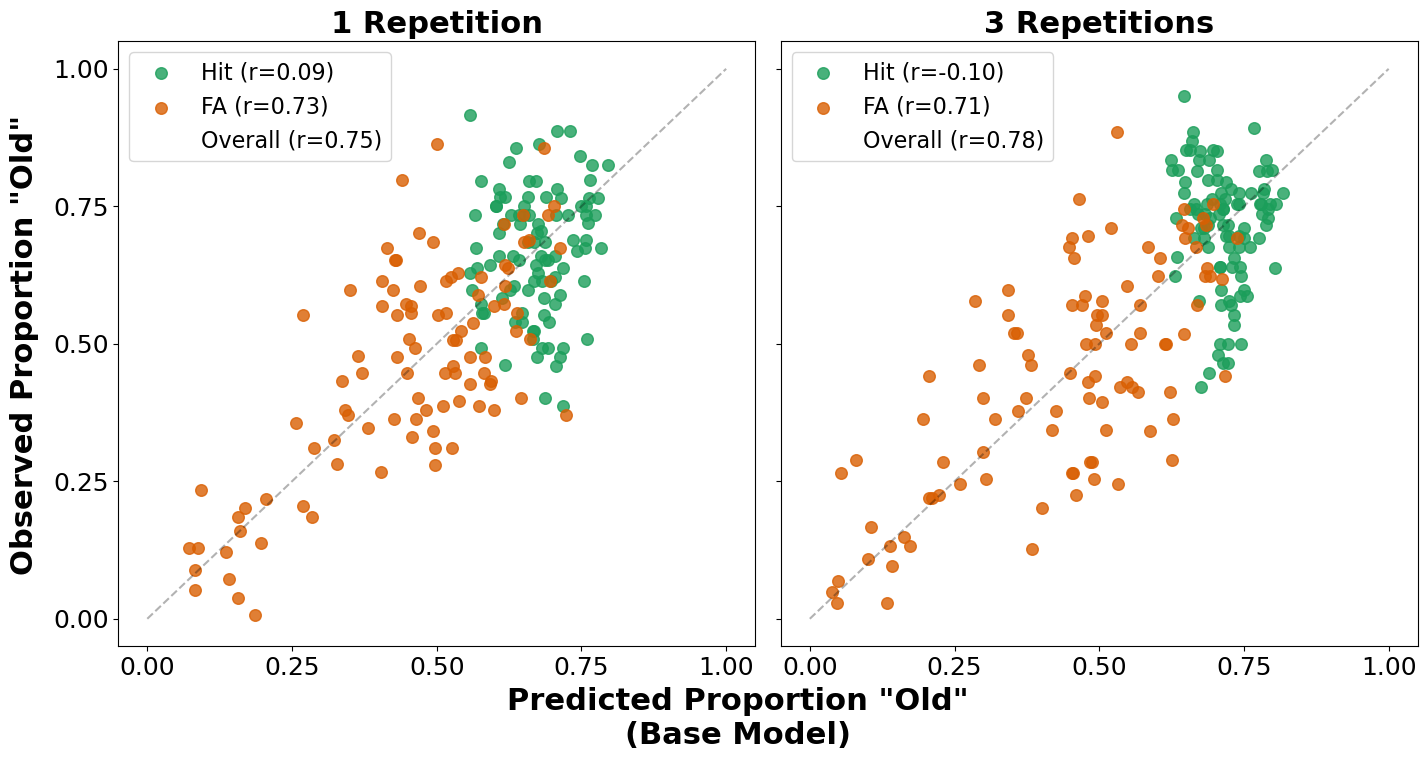

In [188]:
# Observed vs Predicted
fs = 22
fs_axes = 18
fs_legend = 16

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.ravel()
conditions = ['1_Rep', '3_Rep']
condition_labels = ['1 Repetition', '3 Repetitions']
for idx, (condition, condition_label) in enumerate(zip(conditions, condition_labels)):
    df = df_by_item[df_by_item['condition'] == condition]
    # Correlations by response type
    cors = df.groupby('resp_type', observed=True, group_keys=False).apply(
        lambda x: pd.Series(
            stats.pearsonr(x['prop_yes'], x['Base_preds']),
            index=['r', 'p_value']
        ),
        include_groups=False
        ).reset_index()
    
    # ========== Hit ==========
    x = df.loc[df['resp_type']=='Hit', 'Base_preds']
    y = df.loc[df['resp_type']=='Hit', 'prop_yes']

    r = cors.loc[cors['resp_type']=='Hit', 'r'].values[0]

    axes[idx].scatter(x, y, alpha=0.8, s=70, color='#1B9E5A', label=f'Hit (r={r:.2f})')
    
    # ========== FA ==========
    x = df.loc[df['resp_type']=='FA', 'Base_preds']
    y = df.loc[df['resp_type']=='FA', 'prop_yes']

    r = cors.loc[cors['resp_type']=='FA', 'r'].values[0]

    axes[idx].scatter(x, y, alpha=0.8, s=70, color='#D95F02', label=f'FA (r={r:.2f})')
    
    # ========== Overall correlation ==========
    r_overall, p_value_overall = stats.pearsonr(
        df['prop_yes'], df['Base_preds']
        )
    overall_handle = Line2D([], [], linestyle='None',
                            label=f"Overall (r={r_overall:.2f})")
    handles, labels = axes[idx].get_legend_handles_labels()
    
    axes[idx].legend(handles + [overall_handle],
                     labels + [overall_handle.get_label()],
                     fontsize=fs_legend)
    axes[idx].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[idx].set_xlim(-0.05, 1.05)
    axes[idx].set_ylim(-0.05, 1.05)
    axes[idx].set_xticks(np.arange(0, 1.05, 0.25))
    axes[idx].set_yticks(np.arange(0, 1.05, 0.25))
    axes[idx].tick_params(axis='both', labelsize=fs_axes)
    axes[idx].set_title(f'{condition_label}', fontsize=fs, fontweight='bold')

fig.text(0.5, -0.07, 'Predicted Proportion "Old"\n(Base Model)', fontsize=fs, fontweight='bold', ha='center')
fig.text(-0.02, 0.5, 'Observed Proportion "Old"', fontsize=fs, fontweight='bold', va='center', rotation=90)
plt.tight_layout()
plt.show()

In [145]:
# Exact correlations
conds = ['1_Rep', '3_Rep']

for cond in conds:
    df = df_by_item[df_by_item['condition'] == cond]
    # Correlations with p-values
    cors = (df
        .groupby('resp_type', observed=True, group_keys=False)
        .apply(
            lambda x: pd.Series(
                stats.pearsonr(x['prop_yes'], x['Base_preds']),
                index=['r', 'p_value']
            ),
            include_groups=False
            )
        # round to 3 decimals and format p-values
        .assign(
            r = lambda df: df['r'].round(3),
            p_value = lambda df: df['p_value'].map(
                lambda p: "< .001" if p < 0.001 else f"{p:.3f}"
            )
        )
        .reset_index())

    # overall correlation
    r_overall, p_value_overall = stats.pearsonr(
        df['prop_yes'], df['Base_preds']
        )
    cors_overall = pd.DataFrame({
        'resp_type': ['Overall'],
        'r': [round(r_overall, 3)],
        'p_value': ["< .001" if p_value_overall < 0.001 else f"{p_value_overall:.3f}"]
    })

    # combine together
    df_model_correlations = pd.concat([cors, cors_overall], ignore_index=True, axis=0)
    print(f'{"="*10} {cond} {"="*10}')
    print(df_model_correlations, end="\n\n")

========== 1_Rep ==========
  resp_type      r p_value
0        FA  0.732  < .001
1       Hit  0.088   0.382
2   Overall  0.746  < .001

========== 3_Rep ==========
  resp_type      r p_value
0        FA  0.711  < .001
1       Hit -0.104   0.304
2   Overall  0.778  < .001



## H vs FA

### HS model

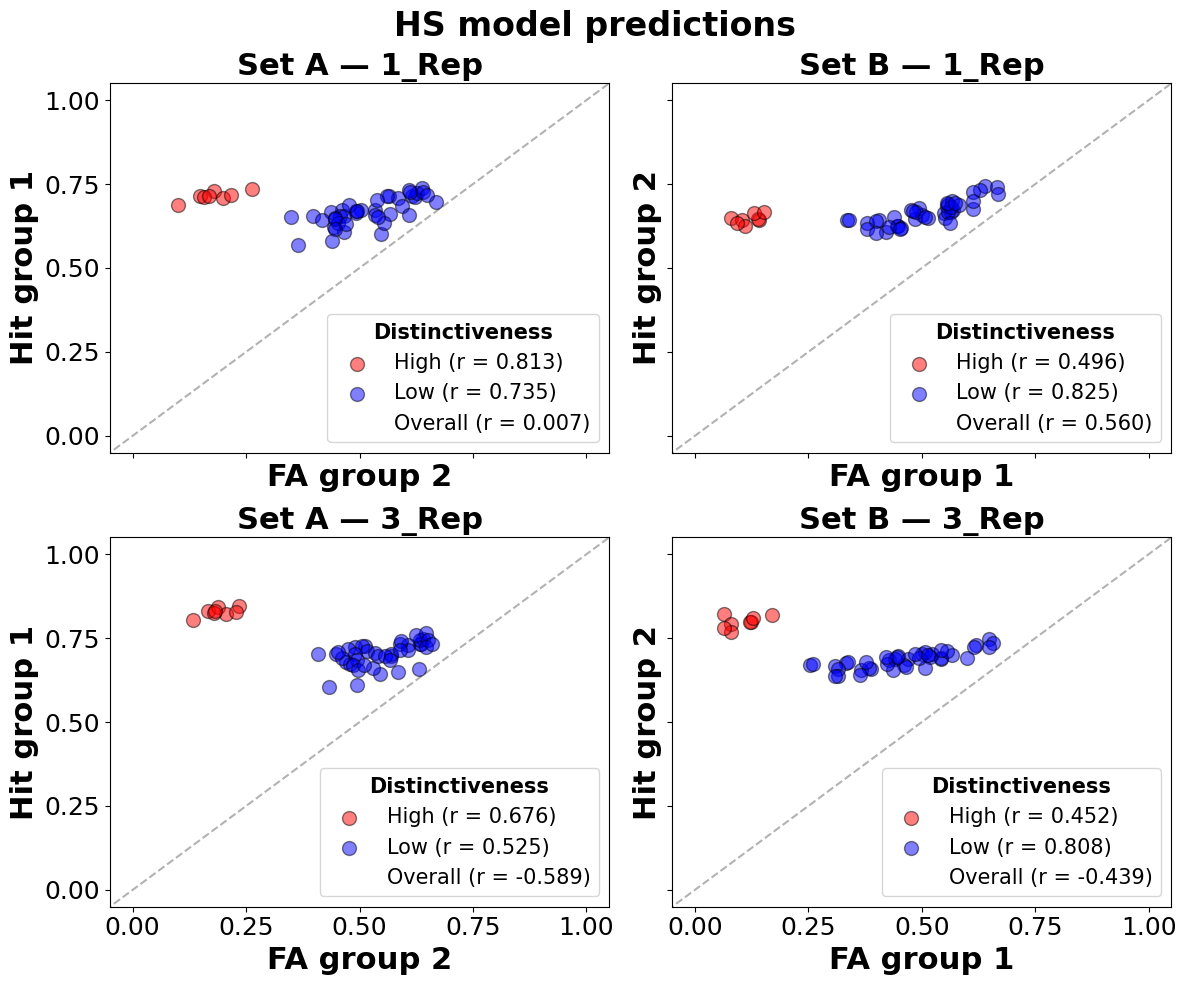

In [173]:
# H vs FA correlations per group and condition (predicted values only!)
conditions = ['1_Rep', '3_Rep']   # top row, bottom row

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True, sharex=True)

distinct_groups = {'Top': 'High', 'Bottom': 'Low'}
colors = ['red', 'blue']

# font sizes
fs = 22
fs_axes = 18
fs_legend = 15

lims = [-0.05, 1.05]

for row_idx, condition in enumerate(conditions):

    # For overall correlations (per subplot)
    x_all_0, y_all_0 = [], []
    x_all_1, y_all_1 = [], []

    for color, distinct in zip(colors, distinct_groups):

        dist_name = distinct_groups[distinct]

        # ---------- Set A (left column) ----------
        ax_left = axes[row_idx, 0]

        x = df_by_item.loc[
            (df_by_item['distinct_type'] == distinct) &
            (df_by_item['group'] == 'Group2') &
            (df_by_item['resp_type'] == 'FA') &
            (df_by_item['condition'] == condition),
            'HS_preds'
        ].reset_index(drop=True)

        y = df_by_item.loc[
            (df_by_item['distinct_type'] == distinct) &
            (df_by_item['group'] == 'Group1') &
            (df_by_item['resp_type'] == 'Hit') &
            (df_by_item['condition'] == condition),
            'HS_preds'
        ].reset_index(drop=True)

        mask = ~(x.isna() | y.isna())
        r = x[mask].corr(y[mask])

        ax_left.scatter(
            x, y, alpha=0.5, edgecolor="k", color=color, s=100,
            label=f"{dist_name} (r = {r:.3f})"
        )

        # ---------- Set B (right column) ----------
        ax_right = axes[row_idx, 1]

        x_rev = df_by_item.loc[
            (df_by_item['distinct_type'] == distinct) &
            (df_by_item['group'] == 'Group1') &
            (df_by_item['resp_type'] == 'FA') &
            (df_by_item['condition'] == condition),
            'HS_preds'
        ].reset_index(drop=True)

        y_rev = df_by_item.loc[
            (df_by_item['distinct_type'] == distinct) &
            (df_by_item['group'] == 'Group2') &
            (df_by_item['resp_type'] == 'Hit') &
            (df_by_item['condition'] == condition),
            'HS_preds'
        ].reset_index(drop=True)

        mask_rev = ~(x_rev.isna() | y_rev.isna())
        r_rev = x_rev[mask_rev].corr(y_rev[mask_rev])

        ax_right.scatter(
            x_rev, y_rev, alpha=0.5, edgecolor="k", color=color, s=100,
            label=f"{dist_name} (r = {r_rev:.3f})"
        )

        # accumulate for overall correlations
        x_all_0.append(x)
        y_all_0.append(y)
        x_all_1.append(x_rev)
        y_all_1.append(y_rev)

    # ---------- Overall correlations ----------
    x0 = pd.concat(x_all_0, ignore_index=True)
    y0 = pd.concat(y_all_0, ignore_index=True)
    x1 = pd.concat(x_all_1, ignore_index=True)
    y1 = pd.concat(y_all_1, ignore_index=True)

    mask0 = ~(x0.isna() | y0.isna())
    mask1 = ~(x1.isna() | y1.isna())

    r0 = x0[mask0].corr(y0[mask0])
    r1 = x1[mask1].corr(y1[mask1])

    overall_handle_0 = Line2D([], [], linestyle='None',
                              label=f"Overall (r = {r0:.3f})")
    overall_handle_1 = Line2D([], [], linestyle='None',
                              label=f"Overall (r = {r1:.3f})")

    # ---------- Formatting per row ----------
    for col in range(2):
        ax = axes[row_idx, col]
        ax.plot([-0.1, 1.1], [-0.1, 1.1], 'k--', alpha=0.3)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xticks(np.arange(0, 1.1, 0.25))
        ax.set_yticks(np.arange(0, 1.1, 0.25))
        ax.tick_params(axis='both', labelsize=fs_axes)

    # titles per row
    axes[row_idx, 0].set_title(f'Set A — {condition}', fontsize=fs, fontweight='bold')
    axes[row_idx, 1].set_title(f'Set B — {condition}', fontsize=fs, fontweight='bold')

    # legends
    handles0, labels0 = axes[row_idx, 0].get_legend_handles_labels()
    axes[row_idx, 0].legend(
        handles0 + [overall_handle_0],
        labels0 + [overall_handle_0.get_label()],
        title="Distinctiveness",
        fontsize=fs_legend,
        title_fontsize=fs_legend,
        loc='lower right'
    )
    axes[row_idx, 0].get_legend().get_title().set_fontweight('bold')

    handles1, labels1 = axes[row_idx, 1].get_legend_handles_labels()
    axes[row_idx, 1].legend(
        handles1 + [overall_handle_1],
        labels1 + [overall_handle_1.get_label()],
        title="Distinctiveness",
        fontsize=fs_legend,
        title_fontsize=fs_legend,
        loc='lower right'
    )
    axes[row_idx, 1].get_legend().get_title().set_fontweight('bold')

# labels
axes[0, 0].set_ylabel('Hit group 1', fontweight='bold', fontsize=fs)
axes[0, 0].set_xlabel('FA group 2', fontweight='bold', fontsize=fs)
axes[1, 0].set_ylabel('Hit group 1', fontweight='bold', fontsize=fs)
axes[1, 0].set_xlabel('FA group 2', fontweight='bold', fontsize=fs)

axes[0, 1].set_ylabel('Hit group 2', fontweight='bold', fontsize=fs)
axes[0, 1].set_xlabel('FA group 1', fontweight='bold', fontsize=fs)
axes[1, 1].set_ylabel('Hit group 2', fontweight='bold', fontsize=fs)
axes[1, 1].set_xlabel('FA group 1', fontweight='bold', fontsize=fs)

fig.suptitle('HS model predictions', fontsize=fs+2, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Exact correlation values for each panel and condition
get_H_vs_FA_correlations(df_by_item, pred_col='HS_preds')

Column: HS_preds

===== CONDITION: 1 Rep =====

Set A (Group2 FA vs Group1 Hit)
  Top: r = 0.81, p = 0.014, n = 8
  Bottom: r = 0.74, p = 0.000, n = 42
  Overall: r = 0.01, p = 0.961, n = 50

Set B (Group1 FA vs Group2 Hit)
  Top: r = 0.50, p = 0.211, n = 8
  Bottom: r = 0.82, p = 0.000, n = 42
  Overall: r = 0.56, p = 0.000, n = 50

===== CONDITION: 3 Reps =====

Set A (Group2 FA vs Group1 Hit)
  Top: r = 0.68, p = 0.066, n = 8
  Bottom: r = 0.53, p = 0.000, n = 42
  Overall: r = -0.59, p = 0.000, n = 50

Set B (Group1 FA vs Group2 Hit)
  Top: r = 0.45, p = 0.261, n = 8
  Bottom: r = 0.81, p = 0.000, n = 42
  Overall: r = -0.44, p = 0.001, n = 50


### Base model

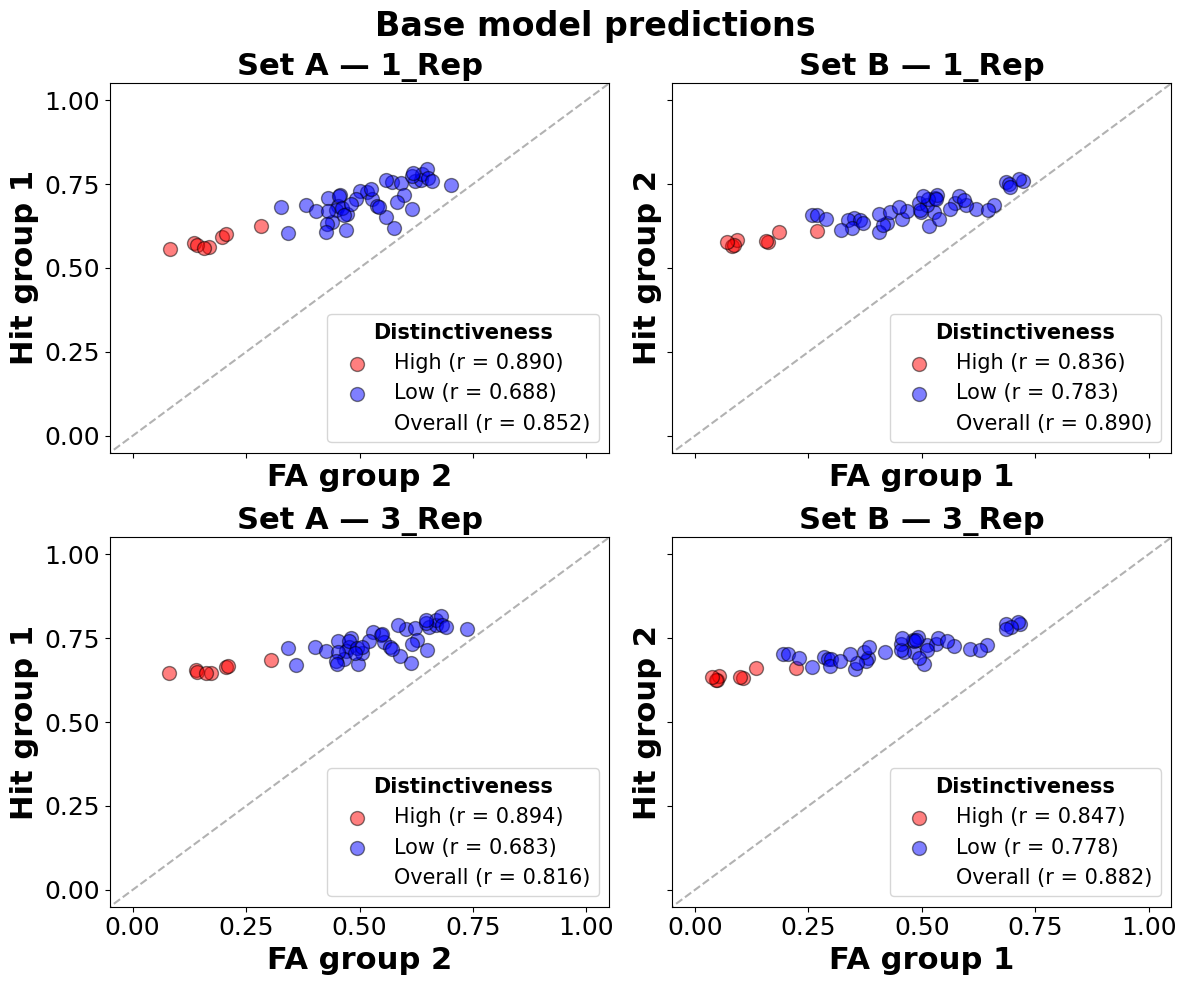

In [177]:
# H vs FA correlations per group and condition (predicted values only!)
conditions = ['1_Rep', '3_Rep']   # top row, bottom row

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True, sharex=True)

distinct_groups = {'Top': 'High', 'Bottom': 'Low'}
colors = ['red', 'blue']

fs = 22
fs_axes = 18
fs_legend = 15

lims = [-0.05, 1.05]

for row_idx, condition in enumerate(conditions):

    x_all_0, y_all_0 = [], []
    x_all_1, y_all_1 = [], []

    for color, distinct in zip(colors, distinct_groups):

        dist_name = distinct_groups[distinct]

        # ---------- Set A (left column) ----------
        ax_left = axes[row_idx, 0]

        x = df_by_item.loc[
            (df_by_item['distinct_type'] == distinct) &
            (df_by_item['group'] == 'Group2') &
            (df_by_item['resp_type'] == 'FA') &
            (df_by_item['condition'] == condition),
            'Base_preds'
        ].reset_index(drop=True)

        y = df_by_item.loc[
            (df_by_item['distinct_type'] == distinct) &
            (df_by_item['group'] == 'Group1') &
            (df_by_item['resp_type'] == 'Hit') &
            (df_by_item['condition'] == condition),
            'Base_preds'
        ].reset_index(drop=True)

        mask = ~(x.isna() | y.isna())
        r = x[mask].corr(y[mask])

        ax_left.scatter(
            x, y, alpha=0.5, edgecolor="k", color=color, s=100,
            label=f"{dist_name} (r = {r:.3f})"
        )

        # ---------- Set B (right column) ----------
        ax_right = axes[row_idx, 1]

        x_rev = df_by_item.loc[
            (df_by_item['distinct_type'] == distinct) &
            (df_by_item['group'] == 'Group1') &
            (df_by_item['resp_type'] == 'FA') &
            (df_by_item['condition'] == condition),
            'Base_preds'
        ].reset_index(drop=True)

        y_rev = df_by_item.loc[
            (df_by_item['distinct_type'] == distinct) &
            (df_by_item['group'] == 'Group2') &
            (df_by_item['resp_type'] == 'Hit') &
            (df_by_item['condition'] == condition),
            'Base_preds'
        ].reset_index(drop=True)

        mask_rev = ~(x_rev.isna() | y_rev.isna())
        r_rev = x_rev[mask_rev].corr(y_rev[mask_rev])

        ax_right.scatter(
            x_rev, y_rev, alpha=0.5, edgecolor="k", color=color, s=100,
            label=f"{dist_name} (r = {r_rev:.3f})"
        )

        x_all_0.append(x)
        y_all_0.append(y)
        x_all_1.append(x_rev)
        y_all_1.append(y_rev)

    # ---------- Overall correlations ----------
    x0 = pd.concat(x_all_0, ignore_index=True)
    y0 = pd.concat(y_all_0, ignore_index=True)
    x1 = pd.concat(x_all_1, ignore_index=True)
    y1 = pd.concat(y_all_1, ignore_index=True)

    mask0 = ~(x0.isna() | y0.isna())
    mask1 = ~(x1.isna() | y1.isna())

    r0 = x0[mask0].corr(y0[mask0])
    r1 = x1[mask1].corr(y1[mask1])

    overall_handle_0 = Line2D([], [], linestyle='None',
                              label=f"Overall (r = {r0:.3f})")
    overall_handle_1 = Line2D([], [], linestyle='None',
                              label=f"Overall (r = {r1:.3f})")

    # ---------- Formatting per row ----------
    for col in range(2):
        ax = axes[row_idx, col]
        ax.plot([-0.1, 1.1], [-0.1, 1.1], 'k--', alpha=0.3)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xticks(np.arange(0, 1.1, 0.25))
        ax.set_yticks(np.arange(0, 1.1, 0.25))
        ax.tick_params(axis='both', labelsize=fs_axes)

    axes[row_idx, 0].set_title(f'Set A — {condition}', fontsize=fs, fontweight='bold')
    axes[row_idx, 1].set_title(f'Set B — {condition}', fontsize=fs, fontweight='bold')

    handles0, labels0 = axes[row_idx, 0].get_legend_handles_labels()
    axes[row_idx, 0].legend(
        handles0 + [overall_handle_0],
        labels0 + [overall_handle_0.get_label()],
        title="Distinctiveness",
        fontsize=fs_legend,
        title_fontsize=fs_legend,
        loc='lower right'
    )
    axes[row_idx, 0].get_legend().get_title().set_fontweight('bold')

    handles1, labels1 = axes[row_idx, 1].get_legend_handles_labels()
    axes[row_idx, 1].legend(
        handles1 + [overall_handle_1],
        labels1 + [overall_handle_1.get_label()],
        title="Distinctiveness",
        fontsize=fs_legend,
        title_fontsize=fs_legend,
        loc='lower right'
    )
    axes[row_idx, 1].get_legend().get_title().set_fontweight('bold')

# labels
axes[0, 0].set_ylabel('Hit group 1', fontweight='bold', fontsize=fs)
axes[0, 0].set_xlabel('FA group 2', fontweight='bold', fontsize=fs)
axes[1, 0].set_ylabel('Hit group 1', fontweight='bold', fontsize=fs)
axes[1, 0].set_xlabel('FA group 2', fontweight='bold', fontsize=fs)

axes[0, 1].set_ylabel('Hit group 2', fontweight='bold', fontsize=fs)
axes[0, 1].set_xlabel('FA group 1', fontweight='bold', fontsize=fs)
axes[1, 1].set_ylabel('Hit group 2', fontweight='bold', fontsize=fs)
axes[1, 1].set_xlabel('FA group 1', fontweight='bold', fontsize=fs)

fig.suptitle('Base model predictions', fontsize=fs+2, fontweight='bold')

plt.tight_layout()
plt.show()

In [175]:
# Exact correlation values for each panel and condition
get_H_vs_FA_correlations(df_by_item, pred_col='Base_preds')

Column: Base_preds

===== CONDITION: 1 Rep =====

Set A (Group2 FA vs Group1 Hit)
  Top: r = 0.89, p = 0.003, n = 8
  Bottom: r = 0.69, p = 0.000, n = 42
  Overall: r = 0.85, p = 0.000, n = 50

Set B (Group1 FA vs Group2 Hit)
  Top: r = 0.84, p = 0.010, n = 8
  Bottom: r = 0.78, p = 0.000, n = 42
  Overall: r = 0.89, p = 0.000, n = 50

===== CONDITION: 3 Reps =====

Set A (Group2 FA vs Group1 Hit)
  Top: r = 0.89, p = 0.003, n = 8
  Bottom: r = 0.68, p = 0.000, n = 42
  Overall: r = 0.82, p = 0.000, n = 50

Set B (Group1 FA vs Group2 Hit)
  Top: r = 0.85, p = 0.008, n = 8
  Bottom: r = 0.78, p = 0.000, n = 42
  Overall: r = 0.88, p = 0.000, n = 50


## Aggregated

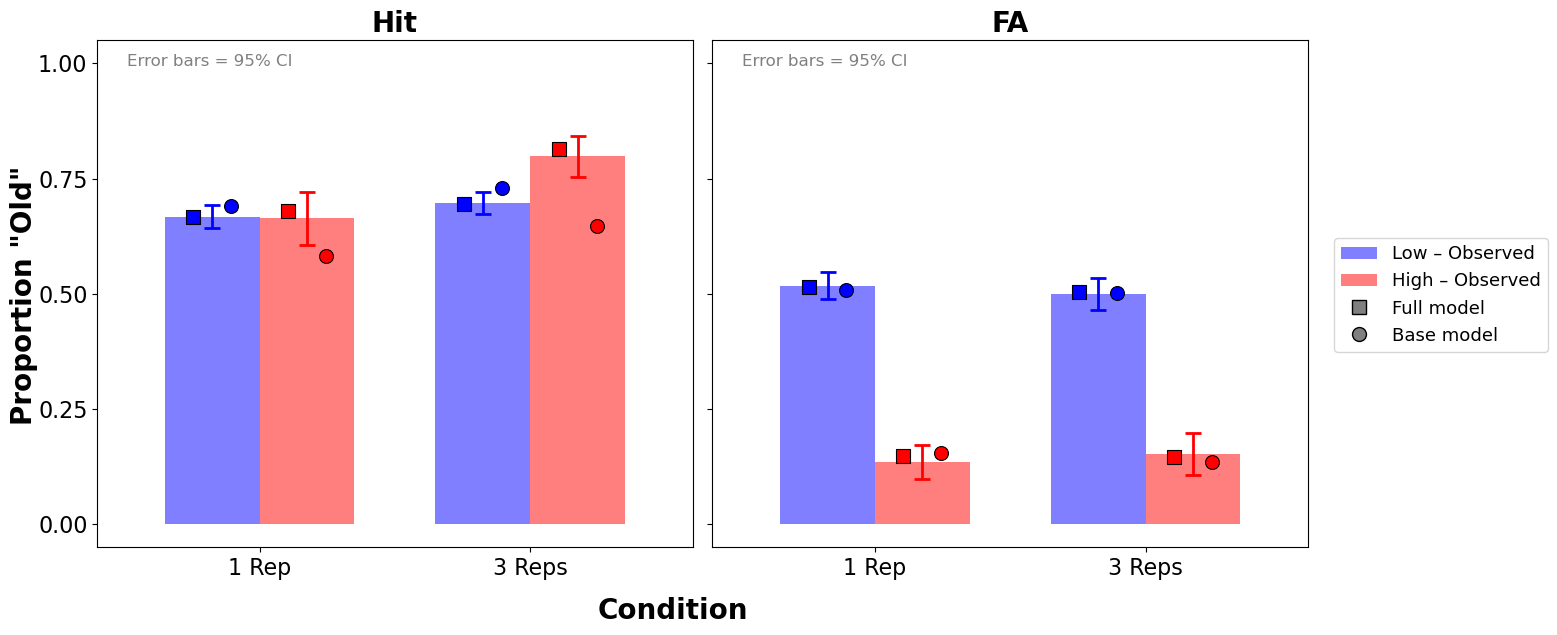

In [178]:
# =============== Summary statistics ===============
summary = (
    df_by_item
    .groupby(["condition", "resp_type", "distinct_type"], observed=False)
    .agg(
        mean_prop=("prop_yes", "mean"),
        mean_hs=("HS_preds", "mean"),
        mean_base=("Base_preds", "mean"),
        n=("prop_yes", "size"),
        sd=("prop_yes", "std")
    )
    .reset_index()
)
summary["se"] = summary["sd"] / np.sqrt(summary["n"])
summary["ci95"] = summary["se"] * stats.t.ppf(0.975, summary["n"] - 1)

# =============== Mappings ===============
resp_levels      = ["Hit", "FA"]
conditions       = ["1_Rep", "3_Rep"]
distinct_levels  = ["Bottom", "Top"]          # x-axis groups

color_map = {"Bottom": "blue", "Top": "red"}
distinct_label_map = {"Bottom": "Low", "Top": "High"}
condition_label_map = {"1_Rep": "1 Rep", "3_Rep": "3 Reps"}

x_pos = np.arange(len(conditions))           # 0, 1
bar_width = 0.35
offsets = {"Bottom": -bar_width / 2, "Top": bar_width / 2}

# marker offsets so the two model predictions don't overlap
model_offset = {"hs": -0.07, "base": 0.07}

fs       = 20
fs_axes  = 16
fs_leg   = 13

# =============== Plot ===============
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

for ax, resp in zip(axes, resp_levels):

    for distinct in distinct_levels:
        color      = color_map[distinct]
        bar_offset = offsets[distinct]

        means, cis, hs_means, base_means = [], [], [], []

        for cond in conditions:
            row = summary[
                (summary["resp_type"]    == resp) &
                (summary["condition"]    == cond) &
                (summary["distinct_type"] == distinct)
            ].iloc[0]
            means.append(row["mean_prop"])
            cis.append(row["ci95"])
            hs_means.append(row["mean_hs"])
            base_means.append(row["mean_base"])

        # ── Observed bars ──
        ax.bar(
            x_pos + bar_offset,
            means,
            width=bar_width,
            color=color,
            alpha=0.5,
            label=f"{distinct_label_map[distinct]} – Observed"
        )
        ax.errorbar(
            x_pos + bar_offset,
            means,
            yerr=cis,
            fmt="none",
            ecolor=color,
            elinewidth=2,
            capsize=6,
            capthick=2
        )

        # ── Full model predictions (squares) ──
        ax.scatter(
            x_pos + bar_offset + model_offset['hs'],
            hs_means,
            marker="s",
            s=100,
            color=color,
            edgecolors="k",
            linewidths=0.8,
            zorder=5,
            label=f"{distinct_label_map[distinct]} – Full model"
        )

        # ── Base model predictions (circles) ──
        ax.scatter(
            x_pos + bar_offset + model_offset['base'],
            base_means,
            marker="o",
            s=100,
            color=color,
            edgecolors="k",
            linewidths=0.8,
            zorder=5,
            label=f"{distinct_label_map[distinct]} – Base model"
        )

    # ── Formatting ──
    ax.set_title(resp, fontsize=fs, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([condition_label_map[c] for c in conditions], fontsize=fs_axes)
    ax.set_xlim(-0.6, len(conditions) - 0.4)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.25))
    ax.tick_params(axis="both", labelsize=fs_axes)
    ax.text(0.05, 0.95, "Error bars = 95% CI",
            transform=ax.transAxes, fontsize=12, color="gray")

# ── Shared legend (deduplicated) ──
handles, labels = axes[0].get_legend_handles_labels()

legend_elements = [
    # Distinctiveness color blocks
    Patch(facecolor="blue", alpha=0.5, label="Low – Observed"),
    Patch(facecolor="red",  alpha=0.5, label="High – Observed"),
    # Model marker types (black so they're neutral)
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=10, label="Full model"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=10, label="Base model"),
]

fig.legend(
    handles=legend_elements,
    loc="center right",
    bbox_to_anchor=(1.18, 0.5),
    fontsize=fs_leg,
    frameon=True,
    title_fontsize=fs_leg
)

fig.text(-0.01, 0.5, 'Proportion "Old"', va="center",
         rotation="vertical", fontsize=fs, fontweight="bold")
fig.text(0.5, -0.04, "Condition", ha="center",
         fontsize=fs, fontweight="bold")

plt.tight_layout()
plt.show()

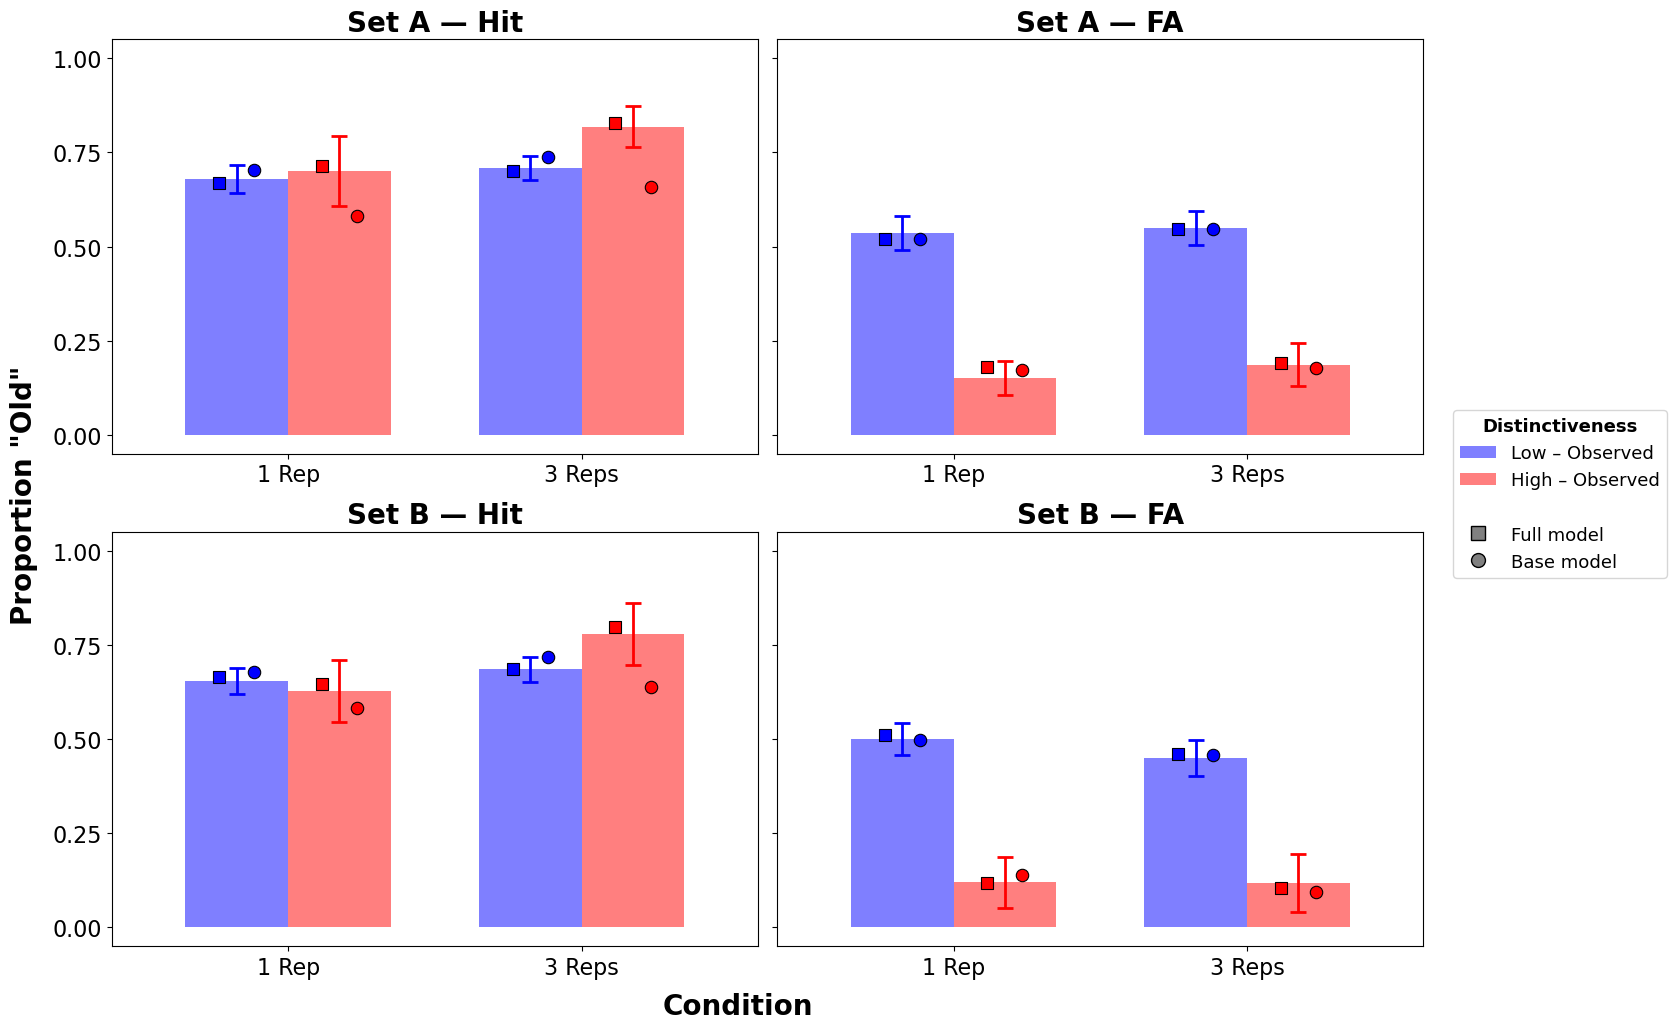

In [ ]:
# By set

# =============== Summary statistics ===============
summary = (
    df_by_item
    .groupby(["condition", "resp_type", "distinct_type", "group"], observed=False)
    .agg(
        mean_prop=("prop_yes", "mean"),
        mean_hs=("HS_preds", "mean"),
        mean_base=("Base_preds", "mean"),
        n=("prop_yes", "size"),
        sd=("prop_yes", "std")
    )
    .reset_index()
)
summary["se"] = summary["sd"] / np.sqrt(summary["n"])
summary["ci95"] = summary["se"] * stats.t.ppf(0.975, summary["n"] - 1)

# =============== Mappings ===============
conditions      = ["1_Rep", "3_Rep"]
distinct_levels = ["Bottom", "Top"]

color_map          = {"Bottom": "blue", "Top": "red"}
distinct_label_map = {"Bottom": "Low", "Top": "High"}
condition_label_map = {"1_Rep": "1 Rep", "3_Rep": "3 Reps"}

# Set A: Hits from Group1, FAs from Group2
# Set B: Hits from Group2, FAs from Group1
sets = {
    "Set A": {"Hit": "Group1", "FA": "Group2"},
    "Set B": {"Hit": "Group2", "FA": "Group1"},
}
resp_levels = ["Hit", "FA"]

x_pos     = np.arange(len(conditions))   # 0, 1
bar_width = 0.35
offsets   = {"Bottom": -bar_width / 2, "Top": bar_width / 2}

# Model prediction markers 
model_offsets = {"hs": -0.06, "base": 0.06}

fs      = 20
fs_axes = 16
fs_leg  = 13

# =============== Plot ===============
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for row_idx, (set_name, group_map) in enumerate(sets.items()):
    for col_idx, resp in enumerate(resp_levels):
        ax    = axes[row_idx, col_idx]
        group = group_map[resp]

        for distinct in distinct_levels:
            color      = color_map[distinct]
            bar_offset = offsets[distinct]

            means, cis, hs_means, base_means = [], [], [], []

            for cond in conditions:
                row = summary[
                    (summary["resp_type"]     == resp)     &
                    (summary["condition"]     == cond)     &
                    (summary["distinct_type"] == distinct) &
                    (summary["group"]         == group)
                ].iloc[0]
                means.append(row["mean_prop"])
                cis.append(row["ci95"])
                hs_means.append(row["mean_hs"])
                base_means.append(row["mean_base"])

            # ── Observed bars ──
            ax.bar(
                x_pos + bar_offset,
                means,
                width=bar_width,
                color=color,
                alpha=0.5,
                label=f"{distinct_label_map[distinct]} – Observed"
            )
            ax.errorbar(
                x_pos + bar_offset,
                means,
                yerr=cis,
                fmt="none",
                ecolor=color,
                elinewidth=2,
                capsize=6,
                capthick=2
            )

            # ── Full model predictions (squares) — outer marker ──
            ax.scatter(
                x_pos + bar_offset + model_offsets["hs"],
                hs_means,
                marker="s",
                s=80,
                color=color,
                edgecolors="k",
                linewidths=0.8,
                zorder=5,
                label=f"{distinct_label_map[distinct]} – Full model"
            )

            # ── Base model predictions (circles) — outermost marker ──
            ax.scatter(
                x_pos + bar_offset + model_offsets["base"],
                base_means,
                marker="o",
                s=80,
                color=color,
                edgecolors="k",
                linewidths=0.8,
                zorder=5,
                label=f"{distinct_label_map[distinct]} – Base model"
            )

        # ── Formatting ──
        ax.set_title(f"{set_name} — {resp}", fontsize=fs, fontweight="bold")
        ax.set_xticks(x_pos)
        ax.set_xticklabels([condition_label_map[c] for c in conditions], fontsize=fs_axes)
        ax.set_xlim(-0.6, len(conditions) - 0.4)
        ax.set_ylim(-0.05, 1.05)
        ax.set_yticks(np.arange(0, 1.1, 0.25))
        ax.tick_params(axis="both", labelsize=fs_axes)

# ── Axis labels ──
fig.text(-0.02, 0.5, 'Proportion "Old"', va="center", rotation="vertical", fontsize=fs, fontweight="bold")
fig.text(0.5, -0.02, "Condition", ha="center", fontsize=fs, fontweight="bold")

# ── Shared legend ──
legend_elements = [
    Patch(facecolor="blue", alpha=0.5, label="Low – Observed"),
    Patch(facecolor="red",  alpha=0.5, label="High – Observed"),
    Line2D([0], [0], marker="None", color="w", markersize=10, label=""),  # spacer
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=10, label="Full model"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markeredgecolor="k", markersize=10, label="Base model"),
]

leg = fig.legend(
    handles=legend_elements,
    loc="center right",
    bbox_to_anchor=(1.17, 0.5),
    fontsize=fs_leg,
    frameon=True,
    title="Distinctiveness",
    title_fontsize=fs_leg
)
leg.get_title().set_fontweight('bold')

plt.tight_layout()
plt.show()

# Model Comparison

In [181]:
# ── AIC / BIC comparison ─────────────────────────────────────────────────────
# AIC = 2k - 2*ln(L)  →  2k + 2*NLL
# BIC = k*ln(n) - 2*ln(L)  →  k*ln(n) + 2*NLL
# where k = number of free parameters, n = number of observations

results_aic_bic = []

for condition in ['1_Rep', '3_Rep']:
    for group in ['Group1', 'Group2']:

        n = len(filtered_data_test.loc[
            (filtered_data_test["group"] == group) &
            (filtered_data_test["condition"] == condition)
        ])

        # ── Full model (c, alpha, beta, k) → k=4
        full_result = optimization_result['HS_model'][(group, condition)]
        nll_full = full_result.fun
        k_full = 4
        aic_full = 2 * k_full + 2 * nll_full
        bic_full = k_full * np.log(n) + 2 * nll_full

        # ── Reduced model (c, k) → k=2
        base_result = optimization_result['Base_model'][(group, condition)]
        nll_base = base_result.fun
        k_base = 2
        aic_base = 2 * k_base + 2 * nll_base
        bic_base = k_base * np.log(n) + 2 * nll_base

        results_aic_bic.append({
            'Group': group,
            'Condition': condition,
            'NLL_HS': round(nll_full, 3),
            'NLL_Base': round(nll_base, 3),
            'AIC_HS': round(aic_full, 3),
            'AIC_Base': round(aic_base, 3),
            'BIC_HS': round(bic_full, 3),
            'BIC_Base': round(bic_base, 3),
        })

df_aic_bic = pd.DataFrame(results_aic_bic)
print(df_aic_bic.to_string(index=False))

 Group Condition   NLL_HS  NLL_Base   AIC_HS  AIC_Base   BIC_HS  BIC_Base
Group1     1_Rep 4100.127  4146.298 8208.255  8296.596 8235.373  8310.155
Group2     1_Rep 3944.544  3950.721 7897.087  7905.442 7923.951  7918.875
Group1     3_Rep 3017.788  3063.069 6043.576  6130.138 6069.644  6143.172
Group2     3_Rep 3526.486  3567.287 7060.972  7138.575 7087.494  7151.836


# Save data

In [210]:
# Save only the variables you actually need
variables_to_save = {
    # all IDs
    'credited_IDs': credited_IDs,
    # Split-half lists
    'split_half_hits_within_dict' : sh_corrs_hits,
    'split_half_fa_within_dict' : sh_corrs_fa,
    'split_half_hits_across_dict' : sh_corrs_hits_across,
    'split_half_fa_across_dict' : sh_corrs_fa_across,

    # Aggregated by item
    'df_by_item': df_by_item,
    'df_by_item_wide': df_by_item_wide,
    
    # Distance matrices
    'dist_mat_gr1': dist_mat_gr1,
    'dist_mat_gr2': dist_mat_gr2,
    
    # Distinctiveness dictionary
    'distinctiveness_image_id': distinctiveness_image_id,
    
    # Optimizers for 
    'optimization_result': optimization_result,
    
    # All data (test and memory phases)
    'filtered_data_test': filtered_data_test,
    'filtered_data_memory': filtered_data_memory,

    # Add other variables you want to keep
}

with open("Exp3_Conditions_analysis.pkl", "wb") as f:
    dill.dump(variables_to_save, f)

In [193]:
# Model comparison summary table
lines = []

# helper to compute n for each group x condition
def get_n(group, condition):
    return len(filtered_data_test.loc[
        (filtered_data_test["group"] == group) &
        (filtered_data_test["condition"] == condition)
    ])

# ── Full model ──────────────────────────────────────────────────────────────
lines.append("FULL MODEL (Hybrid-Similarity Model)")
lines.append("Parameters: c, alpha, beta, k")
lines.append("=" * 80)
lines.append(f"{'Group':<10} {'Condition':<12} {'c':>8} {'alpha':>8} {'beta':>8} {'k':>8} {'NLL':>10} {'AIC':>10} {'BIC':>10}")
lines.append("-" * 80)

for (group, condition), result in optimization_result['HS_model'].items():
    c, alpha, beta, k = [round(x, 3) for x in result.x]
    nll = result.fun
    n   = get_n(group, condition)
    aic = round(2 * 4 + 2 * nll, 3)
    bic = round(4 * np.log(n) + 2 * nll, 3)
    nll = round(nll, 3)
    lines.append(f"{group:<10} {condition:<12} {c:>8} {alpha:>8} {beta:>8} {k:>8} {nll:>10} {aic:>10} {bic:>10}")

# ── Base model ───────────────────────────────────────────────────────────────
lines.append("")
lines.append("")
lines.append("BASE MODEL (Reduced: alpha=0, beta=0 fixed)")
lines.append("Parameters: c, k")
lines.append("=" * 80)
lines.append(f"{'Group':<10} {'Condition':<12} {'c':>8} {'k':>8} {'NLL':>10} {'AIC':>10} {'BIC':>10}")
lines.append("-" * 80)

for (group, condition), result in optimization_result['Base_model'].items():
    c, k = [round(x, 3) for x in result.x]
    nll  = result.fun
    n    = get_n(group, condition)
    aic  = round(2 * 2 + 2 * nll, 3)
    bic  = round(2 * np.log(n) + 2 * nll, 3)
    nll  = round(nll, 3)
    lines.append(f"{group:<10} {condition:<12} {c:>8} {k:>8} {nll:>10} {aic:>10} {bic:>10}")

# ── Write to file ─────────────────────────────────────────────────────────────
output_path = "model_parameters.txt"
with open(output_path, "w") as f:
    f.write("\n".join(lines))

print(f"Saved to {output_path}")
print("\n".join(lines))

Saved to model_parameters.txt
FULL MODEL (Hybrid-Similarity Model)
Parameters: c, alpha, beta, k
Group      Condition           c    alpha     beta        k        NLL        AIC        BIC
--------------------------------------------------------------------------------
Group1     1_Rep           0.521    0.197    0.221    2.116   4100.127   8208.255   8235.373
Group2     1_Rep           0.764    0.031    0.088    1.167   3944.544   7897.087   7923.951
Group1     3_Rep           0.719    0.099    0.263    1.437   3017.788   6043.576   6069.644
Group2     3_Rep           0.595    0.109    0.254    1.703   3526.486   7060.972   7087.494


BASE MODEL (Reduced: alpha=0, beta=0 fixed)
Parameters: c, k
Group      Condition           c        k        NLL        AIC        BIC
--------------------------------------------------------------------------------
Group1     1_Rep           0.878    0.849   4146.298   8296.596   8310.155
Group2     1_Rep           0.874     0.83   3950.721   7905.442